# TC 5035 - Proyecto Integrador
**Avance 2 - Ingeniería de características**

<br>

*   José Raúl Rodríguez Cantú     - A01795469
*   César Julián Camarillo Pérez  - A01795688
*   Joel Alejandro Romero Moya    -	A01168002

<br>

**Objetivos**

*   Crear nuevas características para mejorar el rendimiento de los modelos.
*   Mitigar el riesgo de características sesgadas y acelerar la convergencia de algunos algoritmos.


**Instrucciones**

En esta fase, conocida como ingeniería de características (FE - Feature Engineering):

1. Se aplicarán operaciones comunes para convertir los datos crudos del mundo real, en un conjunto de variables útiles para el aprendizaje automático. El procesamiento puede incluir:
- Generación de nuevas características
- Discretización o binning
- Codificación (ordinal, one hot,…)
- Escalamiento (normalización, estandarización, min – max,…)
- Transformación (logarítmica, exponencial, raíz cuadrada, Box – Cox, Yeo – Johnson,…)

Todas las decisiones y técnicas empleadas deben ser justificadas.

2. Además, se utilizarán métodos de filtrado para la selección de características y técnicas de extracción de características, permitiendo reducir los requerimientos de almacenamiento, la complejidad del modelo y el tiempo de entrenamiento. Los ejemplos siguientes son ilustrativos, pero no exhaustivos, de lo que se podría aplicar:
- Umbral de varianza
- Correlación
- Chi-cuadrado
- ANOVA
- Análisis de componentes principales (PCA)
- Análisis factorial (FA)

Es necesario fundamentar los métodos ejecutados.

3. Incluir conclusiones de la fase de "Preparación de los datos" en el contexto de la metodología CRISP-ML.

**Criterios de evaluación**
- Construcción
- Normalización
- Selección / extracción
- Conclusiones

## 1.Descripción del dataset de entrada

El dataset de entrada utilizado en este avance corresponde a una versión integrada y enriquecida de la información disponible para el proyecto de evaluación de solvencia crediticia de clientes no bancarizados. Este conjunto consolida variables provenientes de distintas fuentes incluyendo perfil sociodemográfico, domicilios registrados, geocodificación y enriquecimiento geográfico. Su propósito es servir como base para construir variables explicativas que permitan aproximar patrones de estabilidad económica, movilidad, ubicación y comportamiento financiero.

Esta etapa se enfoca en comprender la estructura inicial del dataset antes de aplicar ingeniería de características. De acuerdo con el enfoque CRISP-ML(Q), la descripción de los datos es un paso clave para verificar su calidad, identificar posibles inconsistencias y evaluar si la información disponible es suficiente para cumplir los objetivos del modelo de Machine Learning. Por ello, se revisan dimensiones, tipos de variables, valores faltantes, cardinalidad y distribución general de los datos, con el fin de tomar decisiones informadas sobre transformación, codificación, escalamiento y selección de características.

### 1.1 Importar librerías

In [2]:
# ============================================================
# 1. Importación de librerías
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

# Configuración general para visualizar mejor las tablas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### 1.2 Cargar archivo desde Google Drive

In [34]:
# ============================================================
# 2. Conexión con Google Drive y carga del dataset
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Ruta de datos
DATA_PATH = "/content/drive/MyDrive/MNA/9.ProyectoIntegrador/ProyectoFinal_MNA/Avance2_IngenieriaDeCaracteristicas/data/bd_nh_google_maps_enriched.csv"

# Cargamos el dataset enriquecido con Google Maps
df = pd.read_csv(DATA_PATH)

# Revisamos dimensiones generales
print("Dimensiones del dataset:", df.shape)

# Mostramos las primeras filas
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones del dataset: (10000, 33)


,TRACUN_MASK,direccion_sugerida,direccion,latitude,longitude,ESTADO,DIRECCION_SUC,DISTANCE,TUPLE_BUSQ,geocode_status,geocode_error,suc_latitude,suc_longitude,suc_place_id,suc_formatted_address,routes_status,routes_error,gmaps_distance_meters_driving,gmaps_duration_seconds_driving,gmaps_distance_km_driving,accessibility_score,nearby_bank_1km,places_bank_status,places_bank_error,nearby_atm_1km,places_atm_status,places_atm_error,financial_access_score,distance_delta_km,gmaps_distance_available,coord_fuera_mexico,review_distance_delta,places_api_available
0,5997682,"Cerrada de Agua S 124, Nexxus Guadalupe, Apoda...","- CERRADA DEL AGUA SUR 124 ,FRACC FUENTES DE S...",25.703788,-100.148393,Nuevo León,"Carretera Monterrey Reynosa Kilometro 1 402-A,...",4.670113,"('Cerrada de Agua S 124, Nexxus Guadalupe, Apo...",OK,NaN,25.651053,-100.063587,Ej5BdXRvcC4gTW9udGVycmV5IC0gUmV5bm9zYSwgQ2RhZC...,"Autop. Monterrey - Reynosa, Cdad. Benito Juáre...",OK,NaN,14698.0,923.0,14.698,26.51,1.0,OK,NaN,2.0,OK,NaN,40.0,10.027887,1,0,0,1
1,6698534,"39906, Marquésa IV, Acapulco de Juárez, Guerrero","- COND 2 CASA 27 ,FRACC LA MARQUESA IV ,ACAPUL...",16.827100,-99.801900,Guerrero,"Avenida Costera Miguel Alemán 2611, Fraccionam...",6.610198,"('39906, Marquésa IV, Acapulco de Juárez, Guer...",OK,NaN,16.854130,-99.857724,ChIJe7brKC1YyoURi2eSWA7UrQ0,"Av Costera Miguel Alemán 2611, Deportivo, 3969...",OK,NaN,11441.0,1544.0,11.441,42.79,0.0,OK,NaN,0.0,OK,NaN,0.0,4.830802,1,0,0,1
2,5495715,"54140, Unidad Habitacional Tabla Honda, Tlalne...","- EDIFICIO 1 E DEPTO 403 ,U HAB TABLA HONDA ,T...",19.538300,-99.168300,Edo. México,"Avenida Sor Juana Inés de La Cruz 15, Colonia ...",3.037237,"('54140, Unidad Habitacional Tabla Honda, Tlal...",OK,NaN,19.538654,-99.197173,ChIJ960qSVod0oUR0Da7TDfGp_g,"Av Sor Juana Inés de La Cruz 15, Tlalnepantla ...",OK,NaN,4832.0,787.0,4.832,75.84,4.0,OK,NaN,3.0,OK,NaN,100.0,1.794763,1,0,0,1
3,6361026,"Lateral México-Puebla 12, Independencia, Xico,...","-LAT AUT MEXICO PUEBLA MZ 592 LT 12,INDEPENDEN...",19.303570,-98.935178,Edo. México,Avenida Sor Juana Inés de la Cruz 72 Interior ...,13.296164,"('Lateral México-Puebla 12, Independencia, Xic...",OK,NaN,19.388601,-99.024390,EnhBdi4gU29yIEp1YW5hIEluw6lzIGRlIExhIENydXogNz...,Av. Sor Juana Inés de La Cruz 72-interior 109 ...,OK,NaN,15845.0,1465.0,15.845,20.77,2.0,OK,NaN,1.0,OK,NaN,50.0,2.548836,1,0,0,1
4,1165206,"64346, Hacienda Santa Clara, Monterrey, Nuevo ...",". ,HACIENDA SANTA CLARA ,MONTERREY ,64346 ,NL",25.743900,-100.392000,Nuevo León,"Avenida Paseo de los Leones 3270, Colonia Bosq...",1.648358,"('64346, Hacienda Santa Clara, Monterrey, Nuev...",OK,NaN,25.729383,-100.395481,El1BdiBQYXNlbyBkZSBsb3MgTGVvbmVzIDMyNzAsIEJvc3...,"Av Paseo de los Leones 3270, Bosques de Las Cu...",OK,NaN,2349.0,302.0,2.349,88.25,3.0,OK,NaN,1.0,OK,NaN,70.0,0.700642,1,0,0,1


### 1.3 Revisión general de estructura

In [35]:
# ============================================================
# 3. Revisión general de estructura
# ============================================================

print("Columnas del dataset:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes)

print("\nInformación general:")
df.info()

Columnas del dataset:
['TRACUN_MASK', 'direccion_sugerida', 'direccion', 'latitude', 'longitude', 'ESTADO', 'DIRECCION_SUC', 'DISTANCE', 'TUPLE_BUSQ', 'geocode_status', 'geocode_error', 'suc_latitude', 'suc_longitude', 'suc_place_id', 'suc_formatted_address', 'routes_status', 'routes_error', 'gmaps_distance_meters_driving', 'gmaps_duration_seconds_driving', 'gmaps_distance_km_driving', 'accessibility_score', 'nearby_bank_1km', 'places_bank_status', 'places_bank_error', 'nearby_atm_1km', 'places_atm_status', 'places_atm_error', 'financial_access_score', 'distance_delta_km', 'gmaps_distance_available', 'coord_fuera_mexico', 'review_distance_delta', 'places_api_available']

Tipos de datos:


,0
TRACUN_MASK,int64
direccion_sugerida,object
direccion,object
latitude,float64
longitude,float64
ESTADO,object
DIRECCION_SUC,object
DISTANCE,float64
TUPLE_BUSQ,object
geocode_status,object



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   TRACUN_MASK                     10000 non-null  int64  
 1   direccion_sugerida              10000 non-null  object 
 2   direccion                       10000 non-null  object 
 3   latitude                        10000 non-null  float64
 4   longitude                       10000 non-null  float64
 5   ESTADO                          10000 non-null  object 
 6   DIRECCION_SUC                   10000 non-null  object 
 7   DISTANCE                        10000 non-null  float64
 8   TUPLE_BUSQ                      10000 non-null  object 
 9   geocode_status                  6834 non-null   object 
 10  geocode_error                   0 non-null      float64
 11  suc_latitude                    6834 non-null   float64
 12  suc_longitu

### 1.4 Análisis de valores faltantes

In [36]:
# ============================================================
# 4. Análisis de valores faltantes
# ============================================================

missing_summary = pd.DataFrame({
    "tipo_dato": df.dtypes,
    "valores_nulos": df.isna().sum(),
    "porcentaje_nulos": df.isna().mean() * 100,
    "valores_unicos": df.nunique(dropna=True)
}).sort_values("porcentaje_nulos", ascending=False)

display(missing_summary)

,tipo_dato,valores_nulos,porcentaje_nulos,valores_unicos
routes_error,float64,10000,100.00,0
places_atm_error,float64,10000,100.00,0
geocode_error,float64,10000,100.00,0
places_bank_error,float64,10000,100.00,0
nearby_atm_1km,float64,9899,98.99,14
places_bank_status,object,9899,98.99,1
nearby_bank_1km,float64,9899,98.99,16
places_atm_status,object,9899,98.99,1
gmaps_distance_km_driving,float64,3167,31.67,5518
distance_delta_km,float64,3167,31.67,6571


## 2.Construcción de nuevas características

En esta sección se generan nuevas variables a partir del dataset de entrada con el objetivo de representar mejor los patrones asociados a la solvencia crediticia. Las nuevas características buscan capturar señales relevantes como estabilidad laboral, consistencia de ingresos, antigüedad de la relación bancaria, comportamiento histórico de nómina, ubicación geográfica, movilidad y características del entorno. Estas variables permiten transformar datos crudos en información más útil para los modelos de Machine Learning.

La construcción de características se realiza con base en conocimiento del dominio financiero y en criterios de calidad de datos, evitando crear variables redundantes, poco interpretables o potencialmente sesgadas. De acuerdo con CRISP-ML(Q), las características diseñadas deben evaluarse contra una línea base para validar si aportan valor predictivo real y si contribuyen a mejorar el desempeño, la estabilidad y la explicabilidad del modelo.

### 2.1 Crear copia de trabajo

In [37]:
# ============================================================
# 5. Copia de trabajo para ingeniería de características
# ============================================================

df_fe = df.copy()

print("Dataset original:", df.shape)
print("Dataset de trabajo:", df_fe.shape)

Dataset original: (10000, 33)
Dataset de trabajo: (10000, 33)


### 2.2 Crear variables de disponibilidad y calidad de dato

Estas variables son muy importantes porque no solo modelan al cliente, sino también la calidad de la información disponible.

In [38]:
# ============================================================
# 6. Variables de disponibilidad y calidad del dato
# ============================================================

# Indicador de si existe información válida de ruta de Google Maps
df_fe["flag_ruta_disponible"] = df_fe["gmaps_distance_km_driving"].notna().astype(int)

# Indicador de si existe información de duración de viaje
df_fe["flag_duracion_disponible"] = df_fe["gmaps_duration_seconds_driving"].notna().astype(int)

# Indicador de si existe información de accesibilidad
df_fe["flag_accessibility_disponible"] = df_fe["accessibility_score"].notna().astype(int)

# Indicador de si hay datos disponibles de Places API
df_fe["flag_places_disponible"] = df_fe["places_api_available"].fillna(0).astype(int)

# Indicador de posible problema de calidad por coordenadas fuera de México
df_fe["flag_coord_fuera_mexico"] = df_fe["coord_fuera_mexico"].fillna(0).astype(int)

# Indicador de revisión por diferencia relevante entre distancias
df_fe["flag_revision_distancia"] = df_fe["review_distance_delta"].fillna(0).astype(int)

# Revisamos las nuevas variables
display(df_fe[[
    "flag_ruta_disponible",
    "flag_duracion_disponible",
    "flag_accessibility_disponible",
    "flag_places_disponible",
    "flag_coord_fuera_mexico",
    "flag_revision_distancia"
]].head())

,flag_ruta_disponible,flag_duracion_disponible,flag_accessibility_disponible,flag_places_disponible,flag_coord_fuera_mexico,flag_revision_distancia
0,1,1,1,1,0,0
1,1,1,1,1,0,0
2,1,1,1,1,0,0
3,1,1,1,1,0,0
4,1,1,1,1,0,0


Estas variables permiten que el modelo distinga entre clientes con información geográfica completa e incompleta. Esto es relevante porque la ausencia de datos no debe tratarse siempre como un error técnico; en algunos casos puede reflejar limitaciones de cobertura, direcciones incompletas o problemas de calidad en la captura.

### 2.3 Crear variables de distancia, tiempo y movilidad

In [39]:
# ============================================================
# 7. Variables derivadas de distancia, duración y movilidad
# ============================================================

# Convertimos duración de segundos a minutos
df_fe["gmaps_duration_min_driving"] = df_fe["gmaps_duration_seconds_driving"] / 60

# Convertimos duración a horas para calcular velocidad promedio
df_fe["gmaps_duration_hours_driving"] = df_fe["gmaps_duration_seconds_driving"] / 3600

# Velocidad promedio estimada en km/h
# Se evita división entre cero reemplazando duraciones inválidas por NaN
df_fe["gmaps_speed_kmh"] = np.where(
    df_fe["gmaps_duration_hours_driving"] > 0,
    df_fe["gmaps_distance_km_driving"] / df_fe["gmaps_duration_hours_driving"],
    np.nan
)

# Razón de desvío: compara distancia por ruta vs distancia directa o previamente calculada
# Si el valor es cercano a 1, la ruta es similar a la distancia directa.
# Si es mucho mayor a 1, puede indicar baja conectividad vial o una ruta poco directa.
df_fe["route_detour_ratio"] = np.where(
    df_fe["DISTANCE"] > 0,
    df_fe["gmaps_distance_km_driving"] / df_fe["DISTANCE"],
    np.nan
)

# Diferencia absoluta entre distancia original y distancia por Google Maps
df_fe["distance_delta_abs_km"] = df_fe["distance_delta_km"].abs()

# Revisamos variables creadas
display(df_fe[[
    "DISTANCE",
    "gmaps_distance_km_driving",
    "gmaps_duration_min_driving",
    "gmaps_speed_kmh",
    "route_detour_ratio",
    "distance_delta_abs_km"
]].head())

,DISTANCE,gmaps_distance_km_driving,gmaps_duration_min_driving,gmaps_speed_kmh,route_detour_ratio,distance_delta_abs_km
0,4.670113,14.698,15.383333,57.326977,3.147247,10.027887
1,6.610198,11.441,25.733333,26.675907,1.730810,4.830802
2,3.037237,4.832,13.116667,22.103177,1.590920,1.794763
3,13.296164,15.845,24.416667,38.936519,1.191697,2.548836
4,1.648358,2.349,5.033333,28.001325,1.425054,0.700642


Estas variables enriquecen el dataset porque capturan dimensiones más cercanas al contexto real del cliente:

gmaps_duration_min_driving: aproxima el tiempo de traslado a sucursal.
gmaps_speed_kmh: puede capturar condiciones de movilidad o conectividad.
route_detour_ratio: mide qué tan directa o compleja es la ruta.
distance_delta_abs_km: ayuda a detectar inconsistencias entre cálculos de distancia.

En scoring crediticio, estas variables pueden ser útiles como señales indirectas de accesibilidad, cercanía a infraestructura financiera y facilidad de atención en sucursal.

### 2.4 Transformaciones logarítmicas

Las distancias y duraciones suelen estar sesgadas a la derecha. Es decir, la mayoría de clientes vive relativamente cerca, pero algunos pocos tienen distancias extremadamente altas.

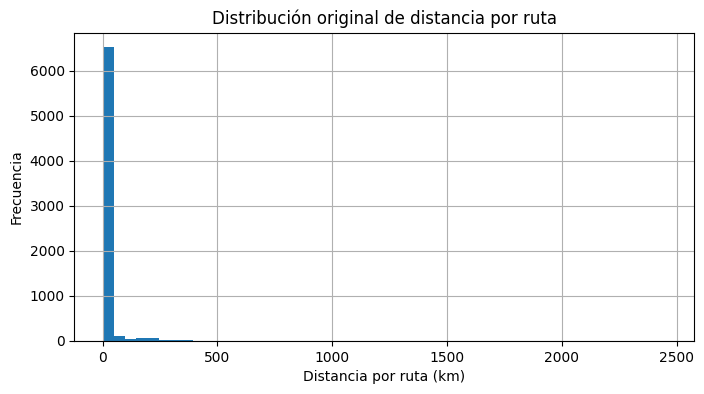

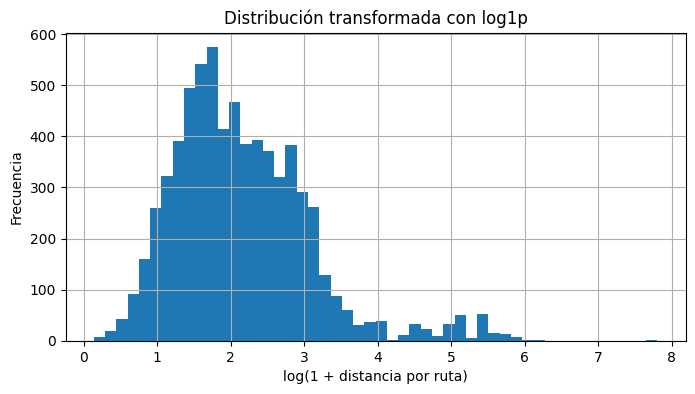

In [40]:
# ============================================================
# 8. Transformaciones logarítmicas para variables sesgadas
# ============================================================

# Aplicamos log1p, que calcula log(1 + x), útil cuando hay ceros
df_fe["log_gmaps_distance_km"] = np.log1p(df_fe["gmaps_distance_km_driving"])
df_fe["log_gmaps_duration_min"] = np.log1p(df_fe["gmaps_duration_min_driving"])
df_fe["log_distance_original"] = np.log1p(df_fe["DISTANCE"])
df_fe["log_distance_delta_abs_km"] = np.log1p(df_fe["distance_delta_abs_km"])

# Visualización comparativa antes y después de la transformación
plt.figure(figsize=(8, 4))
df_fe["gmaps_distance_km_driving"].dropna().hist(bins=50)
plt.title("Distribución original de distancia por ruta")
plt.xlabel("Distancia por ruta (km)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(8, 4))
df_fe["log_gmaps_distance_km"].dropna().hist(bins=50)
plt.title("Distribución transformada con log1p")
plt.xlabel("log(1 + distancia por ruta)")
plt.ylabel("Frecuencia")
plt.show()

La transformación logarítmica reduce el impacto de valores extremos y mejora la estabilidad de algoritmos sensibles a escala y distribución, como regresión logística, SVM, redes neuronales o modelos basados en distancia.

### 2.5 Discretización o binning

La discretización permite convertir variables continuas en rangos interpretables.

In [41]:
# ============================================================
# 9. Discretización de variables relevantes
# ============================================================

# Binning de distancia por ruta
df_fe["bin_distancia_ruta"] = pd.cut(
    df_fe["gmaps_distance_km_driving"],
    bins=[0, 2, 5, 10, 20, 50, np.inf],
    labels=[
        "0-2 km",
        "2-5 km",
        "5-10 km",
        "10-20 km",
        "20-50 km",
        "50+ km"
    ],
    include_lowest=True
)

# Binning de duración por ruta
df_fe["bin_duracion_ruta"] = pd.cut(
    df_fe["gmaps_duration_min_driving"],
    bins=[0, 5, 10, 20, 40, 60, np.inf],
    labels=[
        "0-5 min",
        "5-10 min",
        "10-20 min",
        "20-40 min",
        "40-60 min",
        "60+ min"
    ],
    include_lowest=True
)

# Binning de accesibilidad
df_fe["nivel_accesibilidad"] = pd.cut(
    df_fe["accessibility_score"],
    bins=[-np.inf, 25, 50, 75, np.inf],
    labels=[
        "Muy baja",
        "Baja",
        "Media",
        "Alta"
    ]
)

# Revisamos frecuencias
print("Distribución por bin de distancia:")
display(df_fe["bin_distancia_ruta"].value_counts(dropna=False))

print("\nDistribución por nivel de accesibilidad:")
display(df_fe["nivel_accesibilidad"].value_counts(dropna=False))

Distribución por bin de distancia:


,count
bin_distancia_ruta,
NaN,3167
2-5 km,2126
5-10 km,1667
10-20 km,1458
0-2 km,659
20-50 km,607
50+ km,316



Distribución por nivel de accesibilidad:


,count
nivel_accesibilidad,
NaN,3167
Alta,2784
Media,1668
Muy baja,1498
Baja,883


La discretización mejora la interpretabilidad del modelo y permite capturar relaciones no lineales. Por ejemplo, el efecto de pasar de 2 a 5 km puede no ser equivalente al efecto de pasar de 50 a 100 km.

## 3. Tratamiento de variables

En esta sección se aplican transformaciones necesarias para preparar las variables antes del entrenamiento de modelos de Machine Learning. Se eliminan columnas de texto de alta cardinalidad porque pueden incrementar la dimensionalidad, generar ruido y dificultar la generalización del modelo si no aportan una señal estructurada clara. También se imputan valores nulos para evitar pérdida innecesaria de observaciones y asegurar que los algoritmos puedan procesar el dataset completo de forma consistente.

Adicionalmente, se aplica codificación one-hot a variables categóricas nominales para representarlas numéricamente sin imponer un orden artificial; se escalan las variables numéricas para evitar que diferencias de magnitud dominen el aprendizaje de algunos algoritmos; y se usa transformación logarítmica en variables sesgadas para reducir asimetrías y estabilizar su distribución. Estas decisiones buscan mejorar la calidad del dataset, acelerar la convergencia de ciertos modelos y reducir riesgos asociados a variables inestables, redundantes o mal representadas.

### 3.1 Eliminar columnas que no conviene usar directamente

In [42]:
# ============================================================
# 10. Identificación de columnas a excluir del modelado
# ============================================================

columnas_identificadores = [
    "TRACUN_MASK"
]

columnas_texto_alta_cardinalidad = [
    "direccion_sugerida",
    "direccion",
    "DIRECCION_SUC",
    "TUPLE_BUSQ",
    "suc_place_id",
    "suc_formatted_address"
]

columnas_error_vacias = [
    "geocode_error",
    "routes_error",
    "places_bank_error",
    "places_atm_error"
]

# Las coordenadas exactas pueden funcionar como proxy geográfico sensible.
# Para un modelo de scoring, conviene evitarlas o agregarlas a nivel menos granular.
columnas_geograficas_sensibles = [
    "latitude",
    "longitude",
    "suc_latitude",
    "suc_longitude"
]

# Variables de Places API con cobertura muy baja.
# No se eliminan necesariamente por ser malas, sino porque tienen demasiados nulos.
columnas_places_baja_cobertura = [
    "nearby_bank_1km",
    "nearby_atm_1km",
    "places_bank_status",
    "places_atm_status"
]

columnas_a_excluir = (
    columnas_identificadores
    + columnas_texto_alta_cardinalidad
    + columnas_error_vacias
    + columnas_geograficas_sensibles
    + columnas_places_baja_cobertura
)

# Nos quedamos únicamente con columnas que existen en el dataset
columnas_a_excluir = [col for col in columnas_a_excluir if col in df_fe.columns]

print("Columnas a excluir:")
print(columnas_a_excluir)

Columnas a excluir:
['TRACUN_MASK', 'direccion_sugerida', 'direccion', 'DIRECCION_SUC', 'TUPLE_BUSQ', 'suc_place_id', 'suc_formatted_address', 'geocode_error', 'routes_error', 'places_bank_error', 'places_atm_error', 'latitude', 'longitude', 'suc_latitude', 'suc_longitude', 'nearby_bank_1km', 'nearby_atm_1km', 'places_bank_status', 'places_atm_status']


Estas variables se excluyen porque pueden introducir ruido, problemas de privacidad, alta cardinalidad, fuga de información o sesgos geográficos. En particular, las direcciones y coordenadas exactas pueden hacer que el modelo aprenda patrones excesivamente específicos de localización, reduciendo su capacidad de generalización y aumentando riesgos éticos.

### 3.2 Definir variable objetivo

In [43]:
# ============================================================
# 11. Definición de variable objetivo
# ============================================================

TARGET_COL = None

if TARGET_COL is not None and TARGET_COL in df_fe.columns:
    print(f"Variable objetivo encontrada: {TARGET_COL}")
else:
    print("No se definió variable objetivo. Se realizará preparación no supervisada.")

No se definió variable objetivo. Se realizará preparación no supervisada.


### 3.3 Construir matriz de variables



In [44]:
# ============================================================
# 12. Construcción de matriz de características
# ============================================================

# Eliminamos columnas no recomendadas para modelado
df_model = df_fe.drop(columns=columnas_a_excluir, errors="ignore")

# Si hay variable objetivo, la separamos
if TARGET_COL is not None and TARGET_COL in df_model.columns:
    y = df_model[TARGET_COL]
    X = df_model.drop(columns=[TARGET_COL])
else:
    y = None
    X = df_model.copy()

print("Dimensiones de X:", X.shape)

if y is not None:
    print("Dimensiones de y:", y.shape)

display(X.head())

Dimensiones de X: (10000, 32)


,ESTADO,DISTANCE,geocode_status,routes_status,gmaps_distance_meters_driving,gmaps_duration_seconds_driving,gmaps_distance_km_driving,accessibility_score,financial_access_score,distance_delta_km,gmaps_distance_available,coord_fuera_mexico,review_distance_delta,places_api_available,flag_ruta_disponible,flag_duracion_disponible,flag_accessibility_disponible,flag_places_disponible,flag_coord_fuera_mexico,flag_revision_distancia,gmaps_duration_min_driving,gmaps_duration_hours_driving,gmaps_speed_kmh,route_detour_ratio,distance_delta_abs_km,log_gmaps_distance_km,log_gmaps_duration_min,log_distance_original,log_distance_delta_abs_km,bin_distancia_ruta,bin_duracion_ruta,nivel_accesibilidad
0,Nuevo León,4.670113,OK,OK,14698.0,923.0,14.698,26.51,40.0,10.027887,1,0,0,1,1,1,1,1,0,0,15.383333,0.256389,57.326977,3.147247,10.027887,2.753533,2.796265,1.735209,2.400427,10-20 km,10-20 min,Baja
1,Guerrero,6.610198,OK,OK,11441.0,1544.0,11.441,42.79,0.0,4.830802,1,0,0,1,1,1,1,1,0,0,25.733333,0.428889,26.675907,1.730810,4.830802,2.520997,3.285911,2.029489,1.763154,10-20 km,20-40 min,Baja
2,Edo. México,3.037237,OK,OK,4832.0,787.0,4.832,75.84,100.0,1.794763,1,0,0,1,1,1,1,1,0,0,13.116667,0.218611,22.103177,1.590920,1.794763,1.763360,2.647356,1.395561,1.027747,2-5 km,10-20 min,Alta
3,Edo. México,13.296164,OK,OK,15845.0,1465.0,15.845,20.77,50.0,2.548836,1,0,0,1,1,1,1,1,0,0,24.416667,0.406944,38.936519,1.191697,2.548836,2.824054,3.235405,2.659991,1.266620,10-20 km,20-40 min,Muy baja
4,Nuevo León,1.648358,OK,OK,2349.0,302.0,2.349,88.25,70.0,0.700642,1,0,0,1,1,1,1,1,0,0,5.033333,0.083889,28.001325,1.425054,0.700642,1.208662,1.797300,0.973940,0.531006,2-5 km,5-10 min,Alta


### 3.3 Separar variables numéricas y categóricas

In [45]:
# ============================================================
# 13. Separación de variables numéricas y categóricas
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['DISTANCE', 'gmaps_distance_meters_driving', 'gmaps_duration_seconds_driving', 'gmaps_distance_km_driving', 'accessibility_score', 'financial_access_score', 'distance_delta_km', 'gmaps_distance_available', 'coord_fuera_mexico', 'review_distance_delta', 'places_api_available', 'flag_ruta_disponible', 'flag_duracion_disponible', 'flag_accessibility_disponible', 'flag_places_disponible', 'flag_coord_fuera_mexico', 'flag_revision_distancia', 'gmaps_duration_min_driving', 'gmaps_duration_hours_driving', 'gmaps_speed_kmh', 'route_detour_ratio', 'distance_delta_abs_km', 'log_gmaps_distance_km', 'log_gmaps_duration_min', 'log_distance_original', 'log_distance_delta_abs_km']

Variables categóricas:
['ESTADO', 'geocode_status', 'routes_status', 'bin_distancia_ruta', 'bin_duracion_ruta', 'nivel_accesibilidad']


### 3.4 Imputación, codificación y escalamiento

Aquí se construye un pipeline de preprocesamiento.

In [46]:
# ============================================================
# 14. Pipeline de preprocesamiento
# ============================================================

# Pipeline para variables numéricas:
# 1. Imputa valores faltantes con la mediana.
# 2. Escala con StandardScaler para media 0 y desviación estándar 1.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categóricas:
# 1. Imputa valores faltantes con la categoría "Desconocido".
# 2. Aplica One Hot Encoding.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer permite aplicar transformaciones diferentes según tipo de variable
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Aplicamos el preprocesamiento
X_processed = preprocessor.fit_transform(X)

print("Dimensiones después de preprocesamiento:", X_processed.shape)

Dimensiones después de preprocesamiento: (10000, 71)


Se usa imputación por mediana en variables numéricas porque es robusta ante valores extremos. Para variables categóricas, se utiliza una categoría explícita de “Desconocido” para no perder registros. El escalamiento con StandardScaler permite que variables con escalas distintas tengan impacto comparable en algoritmos sensibles a magnitud.

### 3.5 Recuperar nombres de columnas procesadas

In [48]:
# ============================================================
# 15. Recuperación de nombres de variables procesadas
# ============================================================

# Nombres de variables numéricas
num_cols = numeric_features

# Nombres de variables categóricas después de One Hot Encoding
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]

if len(categorical_features) > 0:
    cat_cols = cat_encoder.get_feature_names_out(categorical_features).tolist()
else:
    cat_cols = []

# Unión de todas las columnas finales
processed_feature_names = num_cols + cat_cols

# Convertimos la matriz procesada a DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names)

display(X_processed_df.head())
print("Número final de variables:", X_processed_df.shape[1])

,DISTANCE,gmaps_distance_meters_driving,gmaps_duration_seconds_driving,gmaps_distance_km_driving,accessibility_score,financial_access_score,distance_delta_km,gmaps_distance_available,coord_fuera_mexico,review_distance_delta,places_api_available,flag_ruta_disponible,flag_duracion_disponible,flag_accessibility_disponible,flag_places_disponible,flag_coord_fuera_mexico,flag_revision_distancia,gmaps_duration_min_driving,gmaps_duration_hours_driving,gmaps_speed_kmh,route_detour_ratio,distance_delta_abs_km,log_gmaps_distance_km,log_gmaps_duration_min,log_distance_original,log_distance_delta_abs_km,ESTADO_Aguascalientes,ESTADO_Campeche,ESTADO_Chihuahua,ESTADO_Coahuila,ESTADO_Colima,ESTADO_Durango,ESTADO_Edo. México,ESTADO_Guanajuato,ESTADO_Guerrero,ESTADO_Jalisco,ESTADO_Michoacán,ESTADO_Morelos,ESTADO_Nuevo León,ESTADO_Puebla,ESTADO_Querétaro,ESTADO_Quintana Roo,ESTADO_San Luis Potosí,ESTADO_Sinaloa,ESTADO_Sonora,ESTADO_Tamaulipas,ESTADO_Yucatán,geocode_status_Desconocido,geocode_status_OK,routes_status_MISSING_COORDINATES,routes_status_NO_ROUTE,routes_status_OK,bin_distancia_ruta_0-2 km,bin_distancia_ruta_10-20 km,bin_distancia_ruta_2-5 km,bin_distancia_ruta_20-50 km,bin_distancia_ruta_5-10 km,bin_distancia_ruta_50+ km,bin_distancia_ruta_Desconocido,bin_duracion_ruta_0-5 min,bin_duracion_ruta_10-20 min,bin_duracion_ruta_20-40 min,bin_duracion_ruta_40-60 min,bin_duracion_ruta_5-10 min,bin_duracion_ruta_60+ min,bin_duracion_ruta_Desconocido,nivel_accesibilidad_Alta,nivel_accesibilidad_Baja,nivel_accesibilidad_Desconocido,nivel_accesibilidad_Media,nivel_accesibilidad_Muy baja
0,-0.068904,0.034102,-0.124583,0.034102,-1.250071,5.669431,0.310689,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,-0.124583,-0.124583,2.353614,0.066488,0.304854,0.826446,0.034543,0.033674,1.563961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.049827,-0.037507,0.158751,-0.037507,-0.642216,-0.081374,0.002242,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,0.158751,0.158751,-0.285039,-0.022640,-0.004107,0.529292,0.870186,0.347285,0.685906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.084960,-0.182812,-0.186633,-0.182812,0.591789,14.295639,-0.177947,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,-0.186633,-0.186633,-0.678690,-0.031443,-0.184597,-0.438883,-0.219587,-0.328287,-0.327361,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.015915,0.059320,0.122707,0.059320,-1.464388,7.107133,-0.133193,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,0.122707,0.122707,0.770438,-0.056563,-0.139768,0.916564,0.783991,1.019205,0.001765,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.098616,-0.237404,-0.407916,-0.237404,1.055148,9.982535,-0.242883,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,-0.407916,-0.407916,-0.170938,-0.041879,-0.249641,-1.147725,-1.670315,-0.777604,-1.011787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Número final de variables: 71


## 4. Selección y extracción de características

En esta sección se aplican técnicas de selección de características para reducir la dimensionalidad del dataset, disminuir ruido y conservar únicamente variables con mayor potencial analítico. Se eliminan columnas con alto porcentaje de valores nulos, columnas constantes y variables altamente correlacionadas, ya que estas pueden aportar poca información, incrementar la complejidad del modelo o generar redundancia entre predictores.

Adicionalmente, cuando se cuenta con una variable objetivo, se aplica selección supervisada para identificar las características con mayor relación estadística respecto al resultado que se desea predecir. Finalmente, se utiliza PCA como técnica exploratoria de extracción de características, con el propósito de analizar si es posible representar la información original en un menor número de componentes, reduciendo dimensionalidad sin perder una proporción significativa de la variabilidad del dataset.

### 4.1 Eliminar variables de baja varianza

In [49]:
# ============================================================
# 16. Selección por umbral de varianza
# ============================================================

# VarianceThreshold elimina variables que prácticamente no cambian.
# Esto ayuda a reducir ruido y complejidad.
selector_var = VarianceThreshold(threshold=0.01)

X_var_selected = selector_var.fit_transform(X_processed_df)

selected_var_features = X_processed_df.columns[selector_var.get_support()].tolist()

X_var_selected_df = pd.DataFrame(X_var_selected, columns=selected_var_features)

print("Variables antes de VarianceThreshold:", X_processed_df.shape[1])
print("Variables después de VarianceThreshold:", X_var_selected_df.shape[1])

display(X_var_selected_df.head())

Variables antes de VarianceThreshold: 71
Variables después de VarianceThreshold: 61


,DISTANCE,gmaps_distance_meters_driving,gmaps_duration_seconds_driving,gmaps_distance_km_driving,accessibility_score,financial_access_score,distance_delta_km,gmaps_distance_available,coord_fuera_mexico,review_distance_delta,places_api_available,flag_ruta_disponible,flag_duracion_disponible,flag_accessibility_disponible,flag_places_disponible,flag_coord_fuera_mexico,flag_revision_distancia,gmaps_duration_min_driving,gmaps_duration_hours_driving,gmaps_speed_kmh,route_detour_ratio,distance_delta_abs_km,log_gmaps_distance_km,log_gmaps_duration_min,log_distance_original,log_distance_delta_abs_km,ESTADO_Chihuahua,ESTADO_Coahuila,ESTADO_Colima,ESTADO_Edo. México,ESTADO_Guanajuato,ESTADO_Guerrero,ESTADO_Jalisco,ESTADO_Michoacán,ESTADO_Nuevo León,ESTADO_Querétaro,ESTADO_Sinaloa,ESTADO_Tamaulipas,geocode_status_Desconocido,geocode_status_OK,routes_status_MISSING_COORDINATES,routes_status_OK,bin_distancia_ruta_0-2 km,bin_distancia_ruta_10-20 km,bin_distancia_ruta_2-5 km,bin_distancia_ruta_20-50 km,bin_distancia_ruta_5-10 km,bin_distancia_ruta_50+ km,bin_distancia_ruta_Desconocido,bin_duracion_ruta_0-5 min,bin_duracion_ruta_10-20 min,bin_duracion_ruta_20-40 min,bin_duracion_ruta_40-60 min,bin_duracion_ruta_5-10 min,bin_duracion_ruta_60+ min,bin_duracion_ruta_Desconocido,nivel_accesibilidad_Alta,nivel_accesibilidad_Baja,nivel_accesibilidad_Desconocido,nivel_accesibilidad_Media,nivel_accesibilidad_Muy baja
0,-0.068904,0.034102,-0.124583,0.034102,-1.250071,5.669431,0.310689,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,-0.124583,-0.124583,2.353614,0.066488,0.304854,0.826446,0.034543,0.033674,1.563961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.049827,-0.037507,0.158751,-0.037507,-0.642216,-0.081374,0.002242,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,0.158751,0.158751,-0.285039,-0.022640,-0.004107,0.529292,0.870186,0.347285,0.685906,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.084960,-0.182812,-0.186633,-0.182812,0.591789,14.295639,-0.177947,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,-0.186633,-0.186633,-0.678690,-0.031443,-0.184597,-0.438883,-0.219587,-0.328287,-0.327361,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.015915,0.059320,0.122707,0.059320,-1.464388,7.107133,-0.133193,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,0.122707,0.122707,0.770438,-0.056563,-0.139768,0.916564,0.783991,1.019205,0.001765,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.098616,-0.237404,-0.407916,-0.237404,1.055148,9.982535,-0.242883,0.680798,-0.017323,-0.120447,9.899995,0.680798,0.680798,0.680798,9.899995,-0.017323,-0.120447,-0.407916,-0.407916,-0.170938,-0.041879,-0.249641,-1.147725,-1.670315,-0.777604,-1.011787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


El umbral de varianza elimina variables con poca variabilidad, las cuales aportan poco al aprendizaje del modelo y pueden incrementar innecesariamente el costo computacional.

### 4.2 Eliminar variables altamente correlacionadas

In [50]:
# ============================================================
# 17. Eliminación de variables altamente correlacionadas
# ============================================================

# Calculamos matriz de correlación absoluta
corr_matrix = X_var_selected_df.corr().abs()

# Tomamos solo el triángulo superior de la matriz para evitar duplicados
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Definimos umbral de correlación
correlation_threshold = 0.90

# Identificamos columnas altamente correlacionadas
to_drop_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

print("Número de variables a eliminar por alta correlación:", len(to_drop_corr))
print(to_drop_corr)

# Eliminamos las columnas correlacionadas
X_corr_selected_df = X_var_selected_df.drop(columns=to_drop_corr)

print("Variables después de eliminar correlación alta:", X_corr_selected_df.shape[1])

Número de variables a eliminar por alta correlación: 22
['gmaps_duration_seconds_driving', 'gmaps_distance_km_driving', 'flag_ruta_disponible', 'flag_duracion_disponible', 'flag_accessibility_disponible', 'flag_places_disponible', 'flag_coord_fuera_mexico', 'flag_revision_distancia', 'gmaps_duration_min_driving', 'gmaps_duration_hours_driving', 'distance_delta_abs_km', 'log_gmaps_distance_km', 'log_gmaps_duration_min', 'geocode_status_Desconocido', 'geocode_status_OK', 'routes_status_MISSING_COORDINATES', 'routes_status_OK', 'bin_distancia_ruta_Desconocido', 'bin_duracion_ruta_60+ min', 'bin_duracion_ruta_Desconocido', 'nivel_accesibilidad_Desconocido', 'nivel_accesibilidad_Media']
Variables después de eliminar correlación alta: 39


La eliminación por correlación reduce redundancia. Por ejemplo, distancia en metros y distancia en kilómetros representan prácticamente la misma información. Mantener ambas puede aumentar complejidad sin aportar valor adicional.

### 4.3 Selección supervisada

In [53]:
# ============================================================
# 18. Selección supervisada de características
# ============================================================

if y is not None:
    # Definimos cuántas mejores variables queremos conservar
    k_features = min(30, X_corr_selected_df.shape[1])

    # SelectKBest con ANOVA F-test para clasificación
    selector_kbest = SelectKBest(score_func=f_classif, k=k_features)

    X_kbest = selector_kbest.fit_transform(X_corr_selected_df, y)

    selected_kbest_features = X_corr_selected_df.columns[selector_kbest.get_support()].tolist()

    scores_df = pd.DataFrame({
        "variable": X_corr_selected_df.columns,
        "score_anova": selector_kbest.scores_
    }).sort_values("score_anova", ascending=False)

    print("Variables seleccionadas por ANOVA:")
    display(scores_df.head(30))

    X_selected_df = pd.DataFrame(X_kbest, columns=selected_kbest_features)

else:
    print("No hay variable objetivo definida. Se omite selección supervisada.")
    X_selected_df = X_corr_selected_df.copy()

No hay variable objetivo definida. Se omite selección supervisada.


### 4.4 PCA como extracción de características


Número de variables antes de PCA: 39
Número de componentes después de PCA: 16
Varianza explicada acumulada: 0.9544176894253451


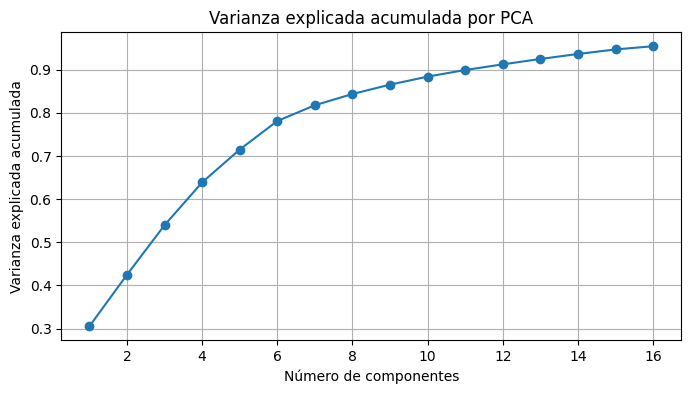

In [54]:
# ============================================================
# 19. Análisis de Componentes Principales PCA
# ============================================================

# PCA busca representar la información original en menos dimensiones.
# Se configura para conservar el 95% de la varianza.
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_corr_selected_df)

print("Número de variables antes de PCA:", X_corr_selected_df.shape[1])
print("Número de componentes después de PCA:", X_pca.shape[1])
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Visualizamos la varianza explicada acumulada
explained_variance_cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance_cumsum) + 1), explained_variance_cumsum, marker="o")
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

PCA permite reducir dimensionalidad y acelerar entrenamiento, especialmente cuando existen variables correlacionadas o muchas variables generadas por codificación one-hot. Sin embargo, para un caso de scoring crediticio, debe usarse con cautela porque disminuye la interpretabilidad de las variables originales.

### 4.5 Guardar dataset final

In [55]:
# ============================================================
# 20. Guardado del dataset final
# ============================================================

OUTPUT_PATH = "/content/drive/MyDrive/MNA/9.ProyectoIntegrador/ProyectoFinal_MNA/Avance2_IngenieriaDeCaracteristicas/data/bd_nh_feature_engineering_ready.csv"

# Si tienes variable objetivo, la agregamos al dataset final
if y is not None:
    df_output = X_selected_df.copy()
    df_output[TARGET_COL] = y.values
else:
    df_output = X_selected_df.copy()

df_output.to_csv(OUTPUT_PATH, index=False)

print("Dataset final guardado en:")
print(OUTPUT_PATH)

print("Dimensiones finales:", df_output.shape)
display(df_output.head())

Dataset final guardado en:
/content/drive/MyDrive/MNA/9.ProyectoIntegrador/ProyectoFinal_MNA/Avance2_IngenieriaDeCaracteristicas/data/bd_nh_feature_engineering_ready.csv
Dimensiones finales: (10000, 39)


,DISTANCE,gmaps_distance_meters_driving,accessibility_score,financial_access_score,distance_delta_km,gmaps_distance_available,coord_fuera_mexico,review_distance_delta,places_api_available,gmaps_speed_kmh,route_detour_ratio,log_distance_original,log_distance_delta_abs_km,ESTADO_Chihuahua,ESTADO_Coahuila,ESTADO_Colima,ESTADO_Edo. México,ESTADO_Guanajuato,ESTADO_Guerrero,ESTADO_Jalisco,ESTADO_Michoacán,ESTADO_Nuevo León,ESTADO_Querétaro,ESTADO_Sinaloa,ESTADO_Tamaulipas,bin_distancia_ruta_0-2 km,bin_distancia_ruta_10-20 km,bin_distancia_ruta_2-5 km,bin_distancia_ruta_20-50 km,bin_distancia_ruta_5-10 km,bin_distancia_ruta_50+ km,bin_duracion_ruta_0-5 min,bin_duracion_ruta_10-20 min,bin_duracion_ruta_20-40 min,bin_duracion_ruta_40-60 min,bin_duracion_ruta_5-10 min,nivel_accesibilidad_Alta,nivel_accesibilidad_Baja,nivel_accesibilidad_Muy baja
0,-0.068904,0.034102,-1.250071,5.669431,0.310689,0.680798,-0.017323,-0.120447,9.899995,2.353614,0.066488,0.033674,1.563961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.049827,-0.037507,-0.642216,-0.081374,0.002242,0.680798,-0.017323,-0.120447,9.899995,-0.285039,-0.022640,0.347285,0.685906,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.084960,-0.182812,0.591789,14.295639,-0.177947,0.680798,-0.017323,-0.120447,9.899995,-0.678690,-0.031443,-0.328287,-0.327361,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.015915,0.059320,-1.464388,7.107133,-0.133193,0.680798,-0.017323,-0.120447,9.899995,0.770438,-0.056563,1.019205,0.001765,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.098616,-0.237404,1.055148,9.982535,-0.242883,0.680798,-0.017323,-0.120447,9.899995,-0.170938,-0.041879,-0.777604,-1.011787,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


En esta fase se realizó ingeniería de características sobre el dataset enriquecido con información geográfica y de rutas proveniente de Google Maps. El objetivo fue transformar variables crudas, como coordenadas, distancias, duración de traslado y disponibilidad de servicios financieros cercanos, en características más útiles para modelos de aprendizaje automático aplicados a evaluación de solvencia crediticia.

Se construyeron variables derivadas de movilidad, accesibilidad y calidad del dato, tales como duración en minutos, velocidad promedio estimada, razón de desvío de ruta, diferencia absoluta entre distancias, indicadores de disponibilidad de rutas y banderas de revisión por inconsistencias geográficas. Estas variables permiten capturar no solo la cercanía física a una sucursal, sino también la facilidad real de desplazamiento y la confiabilidad del enriquecimiento geográfico.

Las variables textuales de alta cardinalidad, como direcciones completas e identificadores de Google Maps, fueron excluidas del modelado para reducir ruido, evitar sobreajuste y mitigar riesgos de privacidad. De igual forma, las coordenadas exactas fueron tratadas con cautela porque pueden funcionar como proxies geográficos sensibles. En su lugar, se favorecieron variables agregadas e interpretables, como distancia, duración, accesibilidad y banderas de calidad.

Para mejorar la estabilidad del modelado, se aplicaron transformaciones logarítmicas a variables con distribuciones sesgadas, discretización de distancias y niveles de accesibilidad, imputación de valores faltantes y escalamiento de variables numéricas. La imputación se realizó mediante la mediana en variables numéricas debido a su robustez ante valores extremos, mientras que las variables categóricas fueron codificadas mediante one-hot encoding.

Finalmente, se aplicaron métodos de selección y extracción de características, incluyendo umbral de varianza, eliminación de variables altamente correlacionadas y PCA como técnica exploratoria de reducción dimensional. Estas técnicas permiten disminuir la complejidad del dataset, reducir tiempos de entrenamiento y facilitar la interpretación de los resultados, manteniendo un equilibrio entre desempeño predictivo, explicabilidad y control de sesgo.

## Informacion de buro

En los siguientes datasets se crearan variables agregadas para las bases de datos de buro, las cuales contienen los registros historicos de las direcciones, consultas de buro, asi como todas las cuentas de creditos que han tenido los clientes en todas las instituciones financieras

### Feature engineering de variables de consultas de buro

In [4]:
#empezamos leyendo los datos y dando los formatos correctos a ciertas variables
bd_info_consultas=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_consultas.txt",sep='|')
bd_info_consultas['IQ_FECHA_CONSULTA']=pd.to_datetime(bd_info_consultas['IQ_FECHA_CONSULTA'].str.split().str[0],format='%Y-%m-%d')

#ordenamos el dataset
bd_info_consultas.sort_values(by=['IQ_PER_ID','IQ_FECHA_CONSULTA','IQ_ID'],ascending=[True,True,False],inplace=True)

#parte para hacer diferencia de dias entre consultas
bd_info_consultas['FECHA_CONSULTA_PREVIA']=bd_info_consultas.groupby(['IQ_PER_ID'])['IQ_FECHA_CONSULTA'].shift(1)
bd_info_consultas['DIF_ENTRE_CONSULTAS']=(bd_info_consultas['IQ_FECHA_CONSULTA']-bd_info_consultas['FECHA_CONSULTA_PREVIA']).dt.days

#catalogo de tipo de consulta segun otorgante
bd_catalogo_tipo_cons=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\Catalogos Buro Catalogo General.csv",encoding='latin1')
bd_catalogo_tipo_cons=bd_catalogo_tipo_cons[['CAT_ID','CAT_DESC']]
bd_catalogo_tipo_cons.rename(columns={'CAT_DESC':'TRAMITE'},inplace=True)

#tenemos el tipo de contrato
bd_info_consultas=bd_info_consultas.merge(bd_catalogo_tipo_cons.rename(
    columns={'CAT_ID':'IQ_TIPO_CONTRATO'}),how='left',on='IQ_TIPO_CONTRATO')

#para saber si hay autoconsultas
bd_info_consultas['FLAG_AUTOCONSULTA']=np.where(((bd_info_consultas['IQ_NAME_OTORG']=='CONSUMIDOR FINAL') & (bd_info_consultas['TRAMITE']=='DESCONOCIDO')),1,0)

#categorizar tramites
bd_clave_tramite=pd.DataFrame({
    'TRAMITE':list(bd_info_consultas['TRAMITE'].unique())
    })

dict_tramite_consultas={
    'TARJETA DE CREDITO':'TDC',
    'OTROS':'OTROS',
    'COMPRA DE AUTOMOVIL':'AUTO',
    'DESCONOCIDO':'DESC',
    'PRESTAMO PERSONAL':'PERS',
    'PRESTAMO PARA ESTUDIANTE':'ESTUD',
    'LINEA DE CREDITO':'LINE',
    'BIENES RAICES':'BIENES',
    'APARATOS/MUEBLES':'MUEBLES',
    'PRESTAMO GARANTIZADO':'PRES_GAR',
    'PRESTAMO PARA PERSONAS FISICAS CON ACTIVIDAD EMPRESARIAL(PFAE)':'PRES_PFAE',
    'ARRENDAMIENTO':'ARREN',
    'TARJETA DE CREDITO EMPRESARIAL':'TDC_EMP',
    'ARRENDAMIENTO AUTOMOTRIZ':'ARREN_AUTO',
    'QUIROGRAFARIO (PFAE)':'QUIR',
    'PRESTAMO NO GARANTIZADO':'PRES_NO_GAR',
    'FIANZA':'FIANZA',
    'TARJETA GARANTIZADA':'TDC_GAR',
    'EQUIPO':'EQUIPO',
    'CREDITO FISCAL':'CRED_FIS',
    'AVIACION':'AVIAC',
    'BOTR / LANCHA':'BOTR'    
    }

bd_clave_tramite['CLAVE_TRAMITE']=bd_clave_tramite['TRAMITE'].map(dict_tramite_consultas)
bd_info_consultas=bd_info_consultas.merge(bd_clave_tramite,how='left',on='TRAMITE')


#categorizar otorgantes
bd_clave_otorg=pd.DataFrame({
    'OTORGANTE':list(bd_info_consultas['IQ_NAME_OTORG'].unique())
    })


dict_otorg_consultas={'AFIRME':'AFIRME',
 'AGROPECUARIO / B':'AGROP',
 'ARRENDADORA AFIR':'ARREND',
 'ARRENDADORAS FIN':'ARREND',
 'ARRENDADORAS NO ':'ARREND',
 'ARRENDAMIENTO':'ARREND',
 'ARRENDAMIENTO / ':'ARREND',
 'AUTOFINANCIAMIEN':'AUTOFIN',
 'AUTOMOTRIZ':'AUTO',
 'AUTOMOTRIZ / BC':'AUTO',
 'BANCA AFIRME':'AFIRME',
 'BANCO':'BANCO',
 'BANCO / BC':'BANCO',
 'BANCOS':'BANCO',
 'BIENES RAICES':'BIENES',
 'BIENES RAICES / ':'BIENES',
 'BURO DE CREDITO ':'BURO',
 'CAJAS DE AHORRO':'CAJAS',
 'CIA Q  OTORGA':'CIA',
 'CIA Q  OTORGA / ':'CIA',
 'COBRANZA / BC':'COB',
 'COMP PETROLERA /':'PETR',
 'COMPANIA DE FINA':'FIN',
 'COMPANIA DE PRES':'PREST',
 'COMUNICACIONES':'COMUNIC',
 'COMUNICACIONES /':'COMUNIC',
 'CONSUMIDOR FINAL':'CONS',
 'COOPERATIVA':'COOP',
 'COOPERATIVA / BC':'COOP',
 'COOPERATIVA DE A':'COOP',
 'EDUCACION':'EDUCACION',
 'EDUCACION / BC':'EDUCACION',
 'FACTORAJE':'FACT',
 'FIANZAS':'FIANZ',
 'FIANZAS / BC':'FIANZ',
 'FINANCIERA':'FINANC',
 'FINANCIERA / BC':'FINANC',
 'FONDOS Y FIDEIC':'FONDOS',
 'FONDOS Y FIDEIC ':'FONDOS',
 'FONDOS Y FIDEICO':'FONDOS',
 'GUBERNAMENTALES':'GOB',
 'GUBERNAMENTALES ':'GOB',
 'HIPOTECAGOBIERNO':'HIP',
 'HIPOTECARIA':'HIP',
 'HIPOTECARIA / BC':'HIP',
 'HIPOTECARIO NO B':'HIP',
 'INSUMOS':'INS',
 'MERCANCIA PARA H':'MERC',
 'MERCANCIA PARA L':'MERC',
 'MICROFINANCIERA':'MICRO',
 'MICROFINANCIERA ':'MICRO',
 'OTROS VEHICULOS ':'AUTO',
 'REPORTE DE CREDI':'REP_CRED',
 'REPORTE ESPECIAL':'REP_ESP',
 'SALUD Y SERVICIO':'SALUD',
 'SEGURO':'SEGURO',
 'SEGURO / BC':'SEGURO',
 'SERVICIO MEDICO ':'SALUD',
 'SERVICIOS':'SERV',
 'SERVICIOS / BC':'SERV',
 'SERVS. GRALES.':'SERV',
 'SERVS. GRALES. /':'SERV',
 'SIC':'SIC',
 'SIC / BC':'SIC',
 'SOCIEDAD FINANCI':'FINANC',
 'SOCIEDADES FINAN':'FINANC',
 'SOFOL PRESTAMO P':'SOFOL',
 'SOFOM-ENR':'SOFOM',
 'SOFOM-ENR / BC':'SOFOM',
 'TELEFONIA CELULA':'TIENDA',
 'TIENDA COMERCIAL':'TIENDA',
 'TIENDA DE AUTOSE':'TIENDA',
 'TIENDA DE ROPA':'TIENDA',
 'TIENDA DEPARTAME':'TIENDA',
 'UNION DE CREDITO':'UNION',
 'VENTA POR CATALO':'VENT_CAT'}


bd_clave_otorg['CLAVE_OTORG']=bd_clave_otorg['OTORGANTE'].map(dict_otorg_consultas)
bd_info_consultas=bd_info_consultas.merge(bd_clave_otorg.rename(columns={'OTORGANTE':'IQ_NAME_OTORG'}),how='left',on='IQ_NAME_OTORG')


#para saber cuantos dias pasaron entre la ultima consulta
bd_info_consultas.sort_values(by=['IQ_PER_ID','CLAVE_OTORG','IQ_FECHA_CONSULTA','IQ_ID'],ascending=[True,True,True,False],inplace=True)
bd_info_consultas['FECHA_PREV_CONSULTA']=bd_info_consultas.groupby(['IQ_PER_ID','CLAVE_OTORG'])['IQ_FECHA_CONSULTA'].shift(1)
bd_ins_last_cons=bd_info_consultas.groupby(['IQ_PER_ID','CLAVE_OTORG']).tail(1)[['IQ_PER_ID','CLAVE_OTORG','IQ_FECHA_CONSULTA','FECHA_PREV_CONSULTA']]
bd_ins_last_cons['DIAS_DESDE_ULTIMA_CONS']=(bd_ins_last_cons['IQ_FECHA_CONSULTA']-bd_ins_last_cons['FECHA_PREV_CONSULTA']).dt.days


#dias entre la ultima consulta por otorgante
bd_last_cons_by_otorg = (
    bd_ins_last_cons
    .pivot_table(
        index="IQ_PER_ID",
        columns="CLAVE_OTORG",
        values="DIAS_DESDE_ULTIMA_CONS"
    )
).reset_index()
bd_last_cons_by_otorg.columns=["DIAS_DESDE_ULT_CONS_OTORG_"+col if col!='IQ_PER_ID' else col for col in bd_last_cons_by_otorg.columns]
bd_info_consultas.rename(columns={'FECHA_PREV_CONSULTA':'FECHA_PREV_CONSULTA_OTORG'},inplace=True)


#dias entre la ultima consulta por tramite
bd_info_consultas.sort_values(by=['IQ_PER_ID','CLAVE_TRAMITE','IQ_FECHA_CONSULTA','IQ_ID'],inplace=True)
bd_info_consultas['FECHA_PREV_CONSULTA']=bd_info_consultas.groupby(['IQ_PER_ID','CLAVE_OTORG'])['IQ_FECHA_CONSULTA'].shift(1)

bd_ins_last_cons=bd_info_consultas.groupby(['IQ_PER_ID','CLAVE_TRAMITE']).tail(1)[['IQ_PER_ID','CLAVE_TRAMITE','IQ_FECHA_CONSULTA','FECHA_PREV_CONSULTA']]
bd_ins_last_cons['DIAS_DESDE_ULTIMA_CONS']=(bd_ins_last_cons['IQ_FECHA_CONSULTA']-bd_ins_last_cons['FECHA_PREV_CONSULTA']).dt.days

bd_last_cons_by_tram = (
    bd_ins_last_cons
    .pivot_table(
        index="IQ_PER_ID",
        columns="CLAVE_TRAMITE",
        values="DIAS_DESDE_ULTIMA_CONS"
    )
).reset_index()

bd_last_cons_by_tram.columns=["DIAS_DESDE_ULT_CONS_TRAM_"+col if col!='IQ_PER_ID' else col for col in bd_last_cons_by_tram.columns]
bd_info_consultas.rename(columns={'FECHA_PREV_CONSULTA':'FECHA_PREV_CONSULTA_TRAM'},inplace=True)


#para saber doas entre consultas
bd_info_consultas.sort_values(by=['IQ_PER_ID','IQ_FECHA_CONSULTA','IQ_ID'],inplace=True)
bd_info_consultas['LAST_IQ_ID']=bd_info_consultas['IQ_ID'].loc[bd_info_consultas.groupby('IQ_PER_ID')['IQ_FECHA_CONSULTA'].rank(method='first',ascending=False)==1]
bd_info_consultas['LAST_IQ_ID']=bd_info_consultas['LAST_IQ_ID'].astype('Int64')
bd_info_consultas['LAST_IQ_ID']=bd_info_consultas['LAST_IQ_ID'].bfill()

bd_info_consultas['FECHA_ULTIMA_CONSULTA']=pd.to_datetime(np.where(bd_info_consultas['IQ_ID']==bd_info_consultas['LAST_IQ_ID'],bd_info_consultas['IQ_FECHA_CONSULTA'],pd.NaT))
bd_info_consultas['FECHA_ULTIMA_CONSULTA']=bd_info_consultas['FECHA_ULTIMA_CONSULTA'].bfill()

bd_info_consultas['FIRST_IQ_ID']=bd_info_consultas['IQ_ID'].loc[bd_info_consultas.groupby('IQ_PER_ID')['IQ_FECHA_CONSULTA'].rank(method='first',ascending=True)==1]
bd_info_consultas['FIRST_IQ_ID']=bd_info_consultas['FIRST_IQ_ID'].astype('Int64')
bd_info_consultas['FIRST_IQ_ID']=bd_info_consultas['FIRST_IQ_ID'].ffill()
bd_info_consultas['FECHA_PRIMER_CONSULTA']=pd.to_datetime(np.where(bd_info_consultas['IQ_ID']==bd_info_consultas['FIRST_IQ_ID'],bd_info_consultas['IQ_FECHA_CONSULTA'],pd.NaT))
bd_info_consultas['FECHA_PRIMER_CONSULTA']=bd_info_consultas['FECHA_PRIMER_CONSULTA'].ffill()
bd_info_consultas['DIF_ENTRE_PRIMER_ULT_CONSULTA']=(bd_info_consultas['FECHA_ULTIMA_CONSULTA']-bd_info_consultas['FECHA_PRIMER_CONSULTA']).dt.days


#promedio de dias entre consultas
bd_group_info_dias_cons=bd_info_consultas.groupby(['IQ_PER_ID']).agg(
    MIN_DIAS_CONS=('DIF_ENTRE_CONSULTAS',min),MAX_DIAS_CONS=('DIF_ENTRE_CONSULTAS',max)
    ,AVG_DIAS_CONS=('DIF_ENTRE_CONSULTAS',np.mean)).reset_index()


#nos traemos la informacion de los nominahabientes que sabemos que si tienen consulta de buro
bd_info_nh_buro=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bd_info_nh_buro.txt",sep='|')
bd_info_nh_buro_cons=bd_info_nh_buro.merge(bd_info_consultas[['IQ_ID','IQ_PER_ID','IQ_FECHA_CONSULTA','CLAVE_TRAMITE','CLAVE_OTORG']]
                                        .rename(columns={'IQ_PER_ID':'ID_BURO_FINAL'}),how='left',on='ID_BURO_FINAL').drop_duplicates(keep='first')
bd_info_nh_buro_cons['FECHA_CONS_FINAL']=pd.to_datetime(bd_info_nh_buro_cons['FECHA_CONS_FINAL'].str.split().str[0],format='%Y-%m-%d').dt.normalize()


#para saber si las consultas entraron en periodos
list_periods=[3,6,9,12,18,24]

for item in list_periods:
    bd_info_nh_buro_cons['FLAG_'+str(item)+"M"]=np.where(bd_info_nh_buro_cons['IQ_FECHA_CONSULTA']
                                            >=bd_info_nh_buro_cons['FECHA_CONS_FINAL']+pd.DateOffset(months=-item),1,0)
bd_info_nh_buro_cons['FLAG_MAS_24M']=np.where(bd_info_nh_buro_cons['IQ_FECHA_CONSULTA']<
                                        bd_info_nh_buro_cons['FECHA_CONS_FINAL']+pd.DateOffset(months=-24),1,0)

#cuantas consultas por 3,6,9,12,18,24 meses por otorg y tram
list_vars_group=['CLAVE_TRAMITE','CLAVE_OTORG']

bd_nh_buro_count_cons_por_tram=pd.DataFrame()
bd_nh_buro_count_cons_por_otorg=pd.DataFrame()

for item in list_vars_group:
    bd_info_nh_buro_cons_group=bd_info_nh_buro_cons.groupby(['ID_BURO_FINAL',item]).agg(
        COUNT_3M=('FLAG_3M',sum)
        ,COUNT_6M=('FLAG_6M',sum)
        ,COUNT_9M=('FLAG_9M',sum)
        ,COUNT_12M=('FLAG_12M',sum)
        ,COUNT_18M=('FLAG_18M',sum)
        ,COUNT_24M=('FLAG_24M',sum)
        ,COUNT_MAS_24M=('FLAG_MAS_24M',sum)
        ).reset_index()
    
    bd_ins_group = (
        bd_info_nh_buro_cons_group
        .pivot_table(
            index="ID_BURO_FINAL",
            columns=item,
            values=["COUNT_3M","COUNT_6M","COUNT_9M","COUNT_12M","COUNT_18M","COUNT_24M","COUNT_MAS_24M"]
        )
    ).reset_index()
    
    bd_ins_group.columns=[f'{metric}_{tramite}' if metric!='ID_BURO_FINAL' else metric for metric,tramite in bd_ins_group.columns]
    if item=='CLAVE_TRAMITE':
        bd_nh_buro_count_cons_por_tram=bd_ins_group.copy()
    else:
        bd_nh_buro_count_cons_por_otorg=bd_ins_group.copy()

bd_nh_buro_count_cons_por_tram=bd_nh_buro_count_cons_por_tram.fillna(0)
bd_nh_buro_count_cons_por_otorg=bd_nh_buro_count_cons_por_otorg.fillna(0)

bd_nh_buro_count_cons_por_tram.columns=[col+"_TRAM" if col!='ID_BURO_FINAL' else col for col in bd_nh_buro_count_cons_por_tram.columns]
bd_nh_buro_count_cons_por_otorg.columns=[col+"_OTORG" if col!='ID_BURO_FINAL' else col for col in bd_nh_buro_count_cons_por_otorg.columns]


list_periods=[3,6,9,12,18,24]
for item in list_periods:
    vect_cols_para_suma=[col for col in bd_nh_buro_count_cons_por_tram.columns if col.split('_')[1]==str(item)+"M"]
    bd_nh_buro_count_cons_por_tram['COUNT_'+str(item)+"M"]=bd_nh_buro_count_cons_por_tram[vect_cols_para_suma].sum(axis=1)

vect_cols_para_suma=[col for col in bd_nh_buro_count_cons_por_tram.columns if col.split('_')[1]=="MAS" and col.split('_')[1]=="24M"]
bd_nh_buro_count_cons_por_tram['COUNT_MAS_24M']=bd_nh_buro_count_cons_por_tram[vect_cols_para_suma].sum(axis=1)

#sumamos cada consulta
bd_nh_buro_count_cons_por_tram['COUNT_GRAL']=bd_nh_buro_count_cons_por_tram[['COUNT_24M','COUNT_MAS_24M']].sum(axis=1)

bd_info_cons_group=bd_info_consultas.groupby('IQ_PER_ID').agg(
    COUNT_AUTOCONS=('FLAG_AUTOCONSULTA',sum)
    ,NUM_DIF_TRAM=('CLAVE_TRAMITE','nunique')
    ,NUM_DIF_CONS=('CLAVE_OTORG','nunique')
    ).reset_index()

bd_master_final_cons=bd_nh_buro_count_cons_por_tram.merge(bd_nh_buro_count_cons_por_otorg,how='left',on='ID_BURO_FINAL').drop_duplicates(keep='first')
bd_master_final_cons=bd_master_final_cons.merge(bd_info_cons_group.rename(columns={'IQ_PER_ID':'ID_BURO_FINAL'}),how='left',on='ID_BURO_FINAL')
bd_master_final_cons=bd_master_final_cons.merge(bd_last_cons_by_tram.drop_duplicates(keep='first').rename(columns={'IQ_PER_ID':'ID_BURO_FINAL'}),how='left',on='ID_BURO_FINAL')
bd_master_final_cons=bd_master_final_cons.merge(bd_last_cons_by_otorg.drop_duplicates(keep='first').rename(columns={'IQ_PER_ID':'ID_BURO_FINAL'}),how='left',on='ID_BURO_FINAL')

C:\Users\cesar\AppData\Local\Temp\ipykernel_35684\4273917335.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  bd_info_consultas=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_consultas.txt",sep='|')
C:\Users\cesar\AppData\Local\Temp\ipykernel_35684\4273917335.py:204: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  bd_group_info_dias_cons=bd_info_consultas.groupby(['IQ_PER_ID']).agg(
C:\Users\cesar\AppData\Local\Temp\ipykernel_35684\4273917335.py:204: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided cal

### Feature engineering de variables de cuentas de buro

In [6]:
#leemos la informacion, que por motivos de optimizacion de extraccion directamente desde la fuente, se tuvo que dividir en 3 partes
bd_info_cuentas1=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_cuentas_1.txt",sep='|',encoding='latin1')
bd_info_cuentas2=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_cuentas_2.txt",sep='|',encoding='latin1')
bd_info_cuentas3=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_cuentas_3.txt",sep='|',encoding='latin1')

bd_info_cuentas=pd.concat([bd_info_cuentas1,bd_info_cuentas2,bd_info_cuentas3],ignore_index=True)

#categorizamos variables segun si estan abiertas o no
bd_info_cuentas['FLAG_CLOSED']=np.where(bd_info_cuentas['TL_FECHA_CIERRE_CTA'].isnull(),1,0)
bd_info_cuentas['FLAG_OPEN']=np.where(bd_info_cuentas['TL_FECHA_CIERRE_CTA'].notnull(),1,0)

#categorizamos los otorgantes
bd_clave_otorg=pd.DataFrame({
    'OTORGANTE':list(bd_info_cuentas['TL_NAME_OTORG'].unique())
    })

dict_otorg_cuentas={'AFIRME':'AFIRME',
'AFIRMECREDITO':'AFIRME',
 'AGROPECUARIO / B':'AGROP',
 'ARRENDADORA AFIR':'ARREND',
 'ARRENDADORAS FIN':'ARREND',
 'ARRENDADORAS NO ':'ARREND',
'ARRENDADORA / BC':'ARREND',    
 'ARRENDAMIENTO':'ARREND',
 'ARRENDAMIENTO / ':'ARREND',
 'AUTOFINANCIAMIEN':'AUTOFIN',
 'AUTOMOTRIZ':'AUTO',
 'AUTOMOTRIZ / BC':'AUTO',
 'BANCA AFIRME':'AFIRME',
 'BANCO':'BANCO',
 'BANCO / BC':'BANCO',
 'BANCOS':'BANCO',
 'BIENES RAICES':'BIENES',
 'BIENES RAICES / ':'BIENES',
 'BURO DE CREDITO ':'BURO',
 'CAJAS DE AHORRO':'CAJAS',
 'CIA Q  OTORGA':'CIA',
 'CIA Q  OTORGA / ':'CIA',
 'COBRANZA':'COB',
 'COBRANZA / BC':'COB',
 'COMP PETROLERA /':'PETR',
 'COMPANIA DE FINA':'FIN',
 'COMPANIA DE PRES':'PREST',
 'COMUNICACIONES':'COMUNIC',
 'COMUNICACIONES /':'COMUNIC',
 'CONSUMIDOR FINAL':'CONS',
 'COOPERATIVA':'COOP',
 'COOPERATIVA / BC':'COOP',
 'COOPERATIVA DE A':'COOP',
 'EDUCACION':'EDUCACION',
 'EDUCACION / BC':'EDUCACION',
 'FACTORAJE':'FACT',
 'FIANZAS':'FIANZ',
 'FIANZAS / BC':'FIANZ',
 'FINANCIERA':'FINANC',
 'FINANCIERA / BC':'FINANC',
 'FONDOS Y FIDEIC':'FONDOS',
 'FONDOS Y FIDEIC ':'FONDOS',
 'FONDOS Y FIDEICO':'FONDOS',
 'GUBERNAMENTALES':'GOB',
 'GUBERNAMENTALES ':'GOB',
 'GOBIERNO / BC':'GOB',
 'GOBIERNO':'GOB',
 'HIPOTECAGOBIERNO':'HIP',
 'HIPOTECARIA':'HIP',
 'HIPOTECARIA / BC':'HIP',
 'HIPOTECARIO NO B':'HIP',
 'INSUMOS':'INS',
 'MERCANCIA PARA H':'MERC',
 'MERCANCIA PARA L':'MERC',
 'MICROFINANCIERA':'MICRO',
 'MICROFINANCIERA ':'MICRO',
 'MIC CREDITO PERS':'MICRO',
 'OTROS VEHICULOS ':'AUTO',
 'OTROS VEHICULOS':'AUTO',
 'OTRAS FINANCIERA':'FINAC',
 'REPORTE DE CREDI':'REP_CRED',
 'REPORTE ESPECIAL':'REP_ESP',
 'SALUD Y SERVICIO':'SALUD',
 'SEGURO':'SEGURO',
 'SEGURO / BC':'SEGURO',
 'SERVICIO MEDICO ':'SALUD',
 'SERVICIO MEDICO':'SALUD',
 'SERVICIOS':'SERV',
 'SERVICIO DE TELE':'TELEF',
 'SERVICIOS / BC':'SERV',
 'SERVS. GRALES.':'SERV',
 'SERVS. GRALES. /':'SERV',
 'SIC':'SIC',
 'SIC / BC':'SIC',
 'SOCIEDAD FINANCI':'FINANC',
 'SOCIEDADES FINAN':'FINANC',
 'SOFOL PRESTAMO P':'SOFOL',
 'SOFOM-ENR':'SOFOM',
 'SOFOM-ENR / BC':'SOFOM',
 'TELEFONIA CELULA':'TELEF',
 'TELEFONIA LOCAL':'TELEF',
 'TELEFONIA LOCAL ':'TELEF',
 'TIENDA COMERCIAL':'TIENDA',
 'TIENDA DE AUTOSE':'TIENDA',
 'TIENDA DE ROPA':'TIENDA',
 'TIENDA DEPARTAME':'TIENDA',
 'UNION DE CREDITO':'UNION',
 'ADMINISTRADORAS':'ADMIN',
 'ADMINISTRADORAS ':'ADMIN',
 'CRED FINAN PFAE':'CREDCOMER',
 'COMERCIAL / BC':'CREDCOMER',
 'SOFOL EMPRESARIA':'SOFOL',
 'SOFOL AUTOMOTRIZ':'SOFOL',
 'EDITORIAL / BC':'EDIT',
 'ADMINISTRADORA D':'ADMIN',
 'VENTA POR CATALO':'VENT_CAT'}

bd_clave_otorg['CLAVE_OTORG']=bd_clave_otorg['OTORGANTE'].map(dict_otorg_cuentas)

list_periods=[1,3,6,9,12,18,24]

#generamos variables para poder revisar los MOPS, los cuales se integran como una cadena de caracteres en donde se especifica el niel de incumplimiento de cadda cuenta
#por ejemplo, un mop 2 indica que la cuenta alcanzo de 1 a 29 dias de atraso
#si queremos sabedr como fue ese estatus en 12 meses tenemos que considerar los primeros 12 caracteres
for item in list_periods:
    bd_info_cuentas['MOP_FOR_'+str(item)+"M"]=bd_info_cuentas['TL_HIST_PAGOS'].apply(str).str[:item]
    for i in range(2,9):
        patron_match='[^'+str(i)+"]+"
        bd_info_cuentas['FLAG_MOP_'+str(i)+"_IN_"+str(item)+"M"]=np.where(
            bd_info_cuentas['MOP_FOR_'+str(item)+"M"].str.replace(patron_match,'',regex=True).apply(len)>0,1,0)


vars_flag_mop_per=[col for col in bd_info_cuentas if col.find('FLAG_MOP_')!=-1]
vars_gral=['TL_ID','TL_PER_ID','TL_FECHA_APERTURA','CLAVE_OTORG','TIP_CTO_CVE','FLAG_CLOSED','FLAG_OPEN']
vars_finales=vars_gral+vars_flag_mop_per


bd_catalogo_tipo_cto=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\Catalogos Buro Tipos Contrato.csv",encoding='latin1')
bd_info_cuentas=bd_info_cuentas.merge(bd_catalogo_tipo_cto[['TIP_CTO_ID','TIP_CTO_CVE']].rename(columns={'TIP_CTO_ID':'TL_TIPO_CONTRATO'}),how='left',on='TL_TIPO_CONTRATO')
bd_info_cuentas=bd_info_cuentas.merge(bd_clave_otorg.rename(columns={'OTORGANTE':'TL_NAME_OTORG'}),how='left',on='TL_NAME_OTORG')

#cargamos la informacion de los nominahabientes
bd_info_nh_buro=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bd_info_nh_buro.txt",sep='|')


bd_info_nh_buro_cuentas=bd_info_nh_buro.merge(bd_info_cuentas[vars_finales]
                                        .rename(columns={'TL_PER_ID':'ID_BURO_FINAL'}),how='left',on='ID_BURO_FINAL').drop_duplicates(keep='first')
bd_info_nh_buro_cuentas['FECHA_CONS_FINAL']=pd.to_datetime(bd_info_nh_buro_cuentas['FECHA_CONS_FINAL'].str.split().str[0],format='%Y-%m-%d').dt.normalize()


#para saber si las consultas entraron en periodos
list_periods=[3,6,9,12,18,24]

for item in list_periods:
    bd_info_nh_buro_cuentas['FLAG_'+str(item)+"M"]=np.where(bd_info_nh_buro_cuentas['TL_FECHA_APERTURA']
                                            >=bd_info_nh_buro_cuentas['FECHA_CONS_FINAL']+pd.DateOffset(months=-item),1,0)
bd_info_nh_buro_cuentas['FLAG_MAS_24M']=np.where(bd_info_nh_buro_cuentas['TL_FECHA_APERTURA']<
                                        bd_info_nh_buro_cuentas['FECHA_CONS_FINAL']+pd.DateOffset(months=-24),1,0)


#analizaremos las variables que hemos generado (si las cuentas tuvieron aperturas en periodos, la situacion de mop y si las cuentas estan abiertas)
#este analisis por tipo de contrato y por tipo de otorogante
list_vars_group=['TIP_CTO_CVE','CLAVE_OTORG']

bd_nh_buro_count_cuentas_por_cto_cve=pd.DataFrame()
bd_nh_buro_count_cuentas_por_otorg=pd.DataFrame()

vars_flag_per=[col for col in bd_info_nh_buro_cuentas.columns if col.find('FLAG')!=-1 and col not in vars_flag_mop_per and col not in ['FLAG_CLOSED','FLAG_OPEN']]
vars_metrics=vars_flag_per+vars_flag_mop_per

bd_info_nh_buro_cuentas.columns
agg_dict = {
    f"COUNT_{c}": (f"{c}", 'sum')
    for c in vars_metrics
}

for item in list_vars_group:
    bd_info_nh_buro_cuentas_group=bd_info_nh_buro_cuentas.groupby(['ID_BURO_FINAL',item]).agg(
        **agg_dict
        ).reset_index()
    
    bd_ins_group = (
        bd_info_nh_buro_cuentas_group
        .pivot_table(
            index="ID_BURO_FINAL",
            columns=item,
            values=["COUNT_"+col for col in vars_metrics]
        )
    ).reset_index()
    
    bd_ins_group.columns=[f'{metric}_{tramite}' if metric!='ID_BURO_FINAL' else metric for metric,tramite in bd_ins_group.columns]
    if item=='TIP_CTO_CVE':
        bd_nh_buro_count_cuentas_por_cto_cve=bd_ins_group.copy()
    else:
        bd_nh_buro_count_cuentas_por_otorg=bd_ins_group.copy()

bd_nh_buro_count_cuentas_por_cto_cve=bd_nh_buro_count_cuentas_por_cto_cve.fillna(0)
bd_nh_buro_count_cuentas_por_otorg=bd_nh_buro_count_cuentas_por_otorg.fillna(0)

bd_master_final_cuentas=bd_nh_buro_count_cuentas_por_cto_cve.merge(bd_nh_buro_count_cuentas_por_otorg,how='left',on='ID_BURO_FINAL').drop_duplicates(keep='first')

C:\Users\cesar\AppData\Local\Temp\ipykernel_35684\2763552986.py:2: DtypeWarning: Columns (7,42) have mixed types. Specify dtype option on import or set low_memory=False.
  bd_info_cuentas1=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_cuentas_1.txt",sep='|',encoding='latin1')
C:\Users\cesar\AppData\Local\Temp\ipykernel_35684\2763552986.py:3: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  bd_info_cuentas2=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_cuentas_2.txt",sep='|',encoding='latin1')


In [54]:
import pandas as pd
import numpy as np

datos_nh=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bd_info_nh_buro.txt",sep='|')
datos=pd.read_csv(r"C:\Users\cesar\OneDrive\Documentos\Maestria en Inteligencia Artificial\8 trimestre\Proyecto Integrador\Primeros codigos\informacion_complementaria\bd_poblacion_buro\bdd_info_buro\bdd_buro_dirs.txt",sep='|')
datos=datos.drop_duplicates(keep='first')
campos = ['PA_DESC', 'PA_COLONIA', 'PA_CP']
# Reemplazar cadenas vacías, None y <NA> por np.nan en todo el DataFrame
datos = datos.replace(['', None], np.nan)

# Ordenamos los datos
datos.sort_values(by=['PA_PER_ID','PA_ID'],ascending=[True, False],inplace=True)
datos[campos]=datos[campos].fillna('')

# Creamos la columnas de informacion previa
datos['PA_DESC_PREVIA'] = datos.groupby(['PA_PER_ID'])['PA_DESC'].shift(1)
datos['PA_COLONIA_PREVIA'] = datos.groupby(['PA_PER_ID'])['PA_COLONIA'].shift(1)
datos['PA_CP_PREVIA'] = datos.groupby(['PA_PER_ID'])['PA_CP'].shift(1).astype('Int64')
datos['PA_FECHA_REP_PREVIA'] = datos.groupby(['PA_PER_ID'])['PA_FECHA_REP'].shift(1)

# Definimos la lista de campos a usar para crear las direcciones

datos['DIRECCION']=datos['PA_DESC']+","+datos['PA_COLONIA']+","+datos['PA_CP'].apply(str)
datos['DIRECCION_PREVIA']=datos['PA_DESC_PREVIA']+","+datos['PA_COLONIA_PREVIA']+","+datos['PA_CP_PREVIA'].apply(str)

# Obtenemos las nuevas direcciones completas
direcciones = datos[['PA_ID','PA_PER_ID','DIRECCION', 'DIRECCION_PREVIA','PA_FECHA_REP','PA_FECHA_REP_PREVIA']].copy()
direcciones['PA_FECHA_REP']=pd.to_datetime(direcciones['PA_FECHA_REP'].apply(str).str.split().str[0],format='%Y-%m-%d').dt.normalize()
direcciones['PA_FECHA_REP_PREVIA']=pd.to_datetime(direcciones['PA_FECHA_REP_PREVIA'].apply(str).str.split().str[0],format='%Y-%m-%d').dt.normalize()

# ========================== Limpieza Direcciones =============================

import pandas as pd
from unidecode import unidecode
import re
from typing import Optional
from nltk.corpus import stopwords

# Funcion que detecta si es texto y que no esta vacio para aplicar unidecode
def safe_unidecode(x):
    if isinstance(x, str) and x.strip() != '':
        return unidecode(x)
    return x 

# Funcion para agregar un espacio antes y despues de un numero
def separar_letras_numeros(texto):
    # Caso 1: letra seguida de número → 'del45' → 'del 45'
    texto = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', texto)
    # Caso 2: número seguido de letra → '45a' → '45 a'
    texto = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', texto)
    return texto

# Eliminar stopwords y palabras de longitud <= 1
def quitar_stopwords(oracion):
    palabras = oracion.split()
    palabras_filtradas = [
        p for p in palabras 
        if p.upper() not in stop_words and len(p) > 1
    ]
    return ' '.join(palabras_filtradas)

# Elimina ceros a la izquieda de los numeros en el texto
def quitar_ceros_izquierda(texto):
    if texto is None:
        return None

    def _reemplazo(m: re.Match) -> str:
        numero = m.group(0)
        return str(int(numero))

    return re.sub(r'\d+', _reemplazo, texto)

# Diccionario para normaizar palabras comunes en las direcciones

normalizacion_dicc = {
    # Vías y tipos de vialidad
    'CALLE': ['C', 'CL', 'CALL', 'CAL', 'CLL', 'CLLE', 'CA'],
    'CALLEJON': ['CJON', 'CJ'],
    'AVENIDA': ['AV', 'AVE', 'AVDA', 'AVD', 'AVN', 'AVNDA'],
    'BOULEVARD': ['BLVD', 'BVD', 'BV', 'BULV', 'BLV'],
    'CARRETERA': ['CARRET', 'CARR', 'CARRE', 'CTRA', 'CAR'],
    'CARRETERA FEDERAL': ['CF'],
    'CARRETERA ESTATAL': ['CE'],
    'CARRETERA MUNICIPAL': ['CM'],
    'CARRETERA NACIONAL': ['CN'],
    'CARRETERA LIBRE': ['CLIB'],
    'CARRETERA CUOTA': ['CCT'],
    'CARRETERA INTERNACIONAL': ['CI'],
    'AUTOPISTA': ['AUT', 'AUTOP', 'AUTP'],
    'AUTOPISTA LIBRE': ['ALIB'],
    'AUTOPISTA CUOTA': ['ACUOT'],
    'AUTOPISTA FEDERAL': ['AF'],
    'CAMINO': ['CAM', 'CMNO', 'CAMN'],
    'ANDADOR': ['AND', 'ANDAD', 'ANDDR'],
    'PROLONGACION': ['PROL', 'PROLG', 'PROLONG', 'PROLN', 'PROLGN'],
    'CIRCUITO': ['CIR', 'CTO', 'CIRC'],
    'CALZADA': ['CALZ', 'CZDA'],
    'PASO': ['PSO'],
    'PASAJE': ['PSJ', 'PASJ', 'PAS'],
    'ESQUINA': ['ESQ', 'ESQN'],
    'VIALIDAD': ['VLD'],
    'CORREDOR': ['CRDR'],
    'PUENTE': ['PNT'], 

    # Ubicaciones/zonas urbanas y rurales
    'COLONIA': ['COL', 'COLN', 'COLON'],
    'FRACCIONAMIENTO': ['FRACC', 'FRAC', 'FRACCION', 'FRACCMT', 'FRACCIONAM', 'FRCC'],
    'CONDOMINIO': ['COND', 'CONJ', 'CONDM', 'CONDMIO'],
    'PRIVADA': ['PRIV', 'PDA', 'PRV', 'PRIVD', 'PRVD'],
    'UNIDAD HABITACIONAL': ['UH', 'U HAB', 'UHAB'],
    'SECTOR': ['SEC', 'SECT'],
    'ZONA': ['ZN', 'ZON'],
    'BARRIO': ['BARR', 'BRR'],
    'CENTRO': ['CTR', 'CNTR', 'CENT'],
    'LOCALIDAD': ['LCLD'],
    'REGION': ['REG', 'RGN'],
    'DISTRITO': ['DST', 'DIST'],
    'MUNICIPIO': ['MPO', 'MUN', 'MUNIC'],
    'PROVINCIA': ['PROV'],
    'ESTADO': ['EDO', 'EST'],
    'PAIS': ['PS'],
    'AREA': ['AR'],

    # Referencias geográficas y naturales
    'CAMPO': ['CMP'],
    'VALLE': ['VLL'],
    'SIERRA': ['SRRA'],
    'CERRO': ['CRRO'],
    'MONTE': ['MNT'],
    'RIO': ['RIO', 'R'],
    'LAGO': ['LGO'],
    'PLAYA': ['PLYA'],
    'COSTA': ['CST'],
    'ISLA': ['ISL'],
    'PARQUE': ['PQ', 'PQUE', 'PRQ'],
    'JARDIN': ['JDN', 'JARD', 'JARDN'],
    'ALDEA': ['ALD'],
    'VEREDA': ['VER', 'VRD'],

    # Orientación cardinal (comunes en MX)
    'NORTE': ['NTE', 'N'],
    'SUR': ['S', 'SR'],
    'ORIENTE': ['OR', 'ORNT', 'E', 'ESTE'],
    'PONIENTE': ['PON', 'O', 'OESTE', 'PTE'],

    # Identificadores numéricos
    'NUMERO': ['NO', 'NUM', 'NRO', 'NUMR', 'NUMERO', 'NÚM'],

    # Predios y subdivisiones
    'MANZANA': ['MZ', 'MZA', 'MNZ'],
    'LOTE': ['LT', 'LOT', 'LOTE'],
    'SECCION': ['SECC'],
    'SOLAR': ['SLR'],
    'TERRENO': ['TRRN'],
    'PARCELA': ['PRCL'],

    # Edificaciones y niveles
    'EDIFICIO': ['EDF', 'EDIF', 'EDFC'],
    'TORRE': ['TOR', 'TRR'],
    'PLANTA': ['PLT'],
    'PISO': ['PIS'],
    'INTERIOR': ['INT', 'IN', 'INTR'],
    'EXTERIOR': ['EXT', 'EX', 'EXTR'],
    'PUERTA': ['PTA'],
    'ENTRADA': ['ENT'],
    'SALIDA': ['SLD'],
    'PATIO': ['PTIO'],
    'CAMPUS': ['CMPUS'],

    # Unidades dentro de edificios
    'OFICINA': ['OF', 'OFNA'],
    'LOCAL': ['LCL', 'LOC'],
    'BODEGA': ['BOD', 'BDG'],
    'ALMACEN': ['ALM', 'ALMC'],
    'DEPARTAMENTO': ['DTO', 'DEPTO', 'DPTO', 'DEPT'],

    # Establecimientos y comercios
    'CENTRO COMERCIAL': ['CC', 'CTR COM'],
    'MERCADO': ['MERC', 'MRCD'],
    'TIENDA': ['TND', 'TDA'],
    'SUPERMERCADO': ['SUP', 'SUPM'],
    'HOTEL': ['HTL', 'HOT'],
    'MOTEL': ['MTL'],
    'POSADA': ['POS', 'PSD'],

    # Salud y educación
    'HOSPITAL': ['HOSP', 'HSPTL'],
    'CLINICA': ['CLNC', 'CLIN'],
    'UNIVERSIDAD': ['UNIV', 'UNI'],
    'ESCUELA': ['ESC', 'ESCL'],
    'INSTITUTO': ['INST', 'INSTT'],

    # Religiosos/culturales
    'IGLESIA': ['IGL', 'IGLES'],
    'TEMPLO': ['TMP', 'TMPL'],
    'CATEDRAL': ['CAT', 'CTDRL'],
    'CAPILLA': ['CAP', 'CPL'],
    'MONASTERIO': ['MON', 'MNST'],
    'CONVENTO': ['CONV', 'CNVT'],

    # Vivienda y propiedades
    'CASA': ['CS', 'CSA'],
    'CHALET': ['CHLT'],
    'VIVIENDA': ['VIV', 'VVD'],
    'RESIDENCIA': ['RES', 'RSD'],
    'PALACIO': ['PAL', 'PLC'],
    'CASTILLO': ['CSTLL'],
    'RANCHO': ['RCH', 'RNCH'],
    'HACIENDA': ['HDA', 'HCND'],
    'FINCA': ['FNC'],

    # Transporte
    'ESTACION': ['ESTAC', 'ESTCN'],
    'TERMINAL': ['TERM', 'TRML', 'TER'],
    'PUERTO': ['PTO', 'PRT'],
    'AEROPUERTO': ['AEROP', 'AEROPTO', 'AERO'],
    'PARADERO': ['PRDR'],
}

# Funcion para crear un diccionario inverso
def construir_indice_inverso(d):
    """
    Construye un índice inverso: abreviatura -> clave canónica.
    Valida que no existan duplicados (la misma abreviatura en dos claves).
    """
    inverso: dict[str, str] = {}
    for clave, lista in d.items():
        for abreviatura in lista:
            if abreviatura in inverso:
                raise ValueError(
                    f"Duplicado: la abreviatura '{abreviatura}' ya está asignada a '{inverso[abreviatura]}' "
                    f"y se intentó reasignar a '{clave}'."
                )
            inverso[abreviatura] = clave
    return inverso  #

# Creamos el diccionario inverso
diccionario_direcciones = construir_indice_inverso(normalizacion_dicc)

# Funcion para reemplazar las abreviaciones de las palabras
def reemplazar_palabras(oracion, idx):
    palabras = oracion.split()
    resultado = [idx.get(p, p) for p in palabras]
    salida = ' '.join(resultado)
    return salida

# Lista de diptongos válidos en español
diptongos_validos = {
    'AI','AU','EI','EU','OI','OU','UI','UA','IE','IO','UE','UO','IU'}

def eliminar_repeticiones(texto):
    if not isinstance(texto, str):
        return texto
    
    # 1. Reducir vocales duplicadas
    texto = re.sub(r'([AEIOUaeiou])\1+', r'\1', texto)
    
    # 2. Reducir consonantes duplicadas no permitidas (excepto LL, RR, CC)
    texto = re.sub(r'([^AEIOULLRRCCaeiou])\1+', r'\1', texto)
    
    # 3. Validar diptongos: si aparece una secuencia de dos vocales que no está en la lista, se simplifica
    def validar_diptongo(match):
        secuencia = match.group(0).upper()
        return secuencia if secuencia in diptongos_validos else secuencia[0]
    
    texto = re.sub(r'[AEIOUaeiou]{2}', validar_diptongo, texto)
    return texto

# Copiamos los datos en una nuevo df
direcciones_limpias = direcciones.copy()

# Cargamos la lista de stopwords en mayusculas
stop_words = set([w.upper() for w in stopwords.words('spanish')])

# Limpiamos las columnas de texto
for col in direcciones_limpias.select_dtypes(include='object').columns:
    
    # Eliminamos vocales repetidas consecutivas
    direcciones_limpias[col] = direcciones_limpias[col].apply(eliminar_repeticiones)

    # Cambiamos acentos y caracteres especiales
    direcciones_limpias[col] = direcciones_limpias[col].apply(safe_unidecode)
    
    # Eliminamos aquello que no sean letras, numeros o espacios
    direcciones_limpias[col] = direcciones_limpias[col].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', str(x)))
    
    # Eliminar espacios duplicados y espacios al inicio y al final
    direcciones_limpias[col] = direcciones_limpias[col].apply(separar_letras_numeros)
    
    # Eliminamos stopwords y palabras con longitud menor a 1
    direcciones_limpias[col] = direcciones_limpias[col].apply(quitar_stopwords)
    
    # Eliminar ceros a la izquieda: 004 a 4
    direcciones_limpias[col] = direcciones_limpias[col].apply(quitar_ceros_izquierda)
          
    # Cambiar abrevianos: Av por Avenida
    direcciones_limpias[col] = direcciones_limpias[col].apply(lambda x: reemplazar_palabras(x, diccionario_direcciones))
    
# ========================= Comparacion Direcciones ===========================


from rapidfuzz import fuzz

def match_fzz(row, columna1, columna2, func):
    if pd.isna(row[columna1]) or pd.isna(row[columna2]):
        return np.nan
    else:
        return func(row[columna1].lower(), row[columna2].lower())

# Obtenemos la porcentaje de match entre direcciones
direcciones_limpias['MATCH_DIRECCION'] = direcciones_limpias.apply(
    lambda row: match_fzz(row, 'DIRECCION', 'DIRECCION_PREVIA', fuzz.token_set_ratio), axis=1)


direcciones_limpias['MATCH_DIRECCION']=np.where(direcciones_limpias['DIRECCION_PREVIA']=='nan',np.NaN,direcciones_limpias['MATCH_DIRECCION'])



#comparamos fecha de registro de direccion contra la fecha de la ultima consulta para cada nominahabientes
bd_nh_dirs=datos_nh.merge(direcciones_limpias.rename(columns={'PA_PER_ID':'ID_BURO_FINAL'}),how='left',on='ID_BURO_FINAL').drop_duplicates(keep='first')
bd_nh_dirs['FLAG_3M']=np.where((bd_nh_dirs['PA_FECHA_REP']-bd_nh_dirs['PA_FECHA_REP_PREVIA'])/np.timedelta64(1,'m')<=3,1,0)
bd_nh_dirs['FLAG_6M']=np.where((bd_nh_dirs['PA_FECHA_REP']-bd_nh_dirs['PA_FECHA_REP_PREVIA'])/np.timedelta64(1,'m')<=6,1,0)
bd_nh_dirs['FLAG_9M']=np.where((bd_nh_dirs['PA_FECHA_REP']-bd_nh_dirs['PA_FECHA_REP_PREVIA'])/np.timedelta64(1,'m')<=9,1,0)
bd_nh_dirs['FLAG_12M']=np.where((bd_nh_dirs['PA_FECHA_REP']-bd_nh_dirs['PA_FECHA_REP_PREVIA'])/np.timedelta64(1,'m')<=12,1,0)
bd_nh_dirs['FLAG_18M']=np.where((bd_nh_dirs['PA_FECHA_REP']-bd_nh_dirs['PA_FECHA_REP_PREVIA'])/np.timedelta64(1,'m')<=18,1,0)
bd_nh_dirs['FLAG_24M']=np.where((bd_nh_dirs['PA_FECHA_REP']-bd_nh_dirs['PA_FECHA_REP_PREVIA'])/np.timedelta64(1,'m')<=24,1,0)

#evlauamos si ha habido un cambio de domicilio en la periodicidad revisada
bd_nh_dirs['FLAG_CAMBIO_3M']=np.where((bd_nh_dirs['FLAG_3M']==1) & (bd_nh_dirs['MATCH_DIRECCION'].fillna(100)<60),1,0)
bd_nh_dirs['FLAG_CAMBIO_6M']=np.where((bd_nh_dirs['FLAG_6M']==1) & (bd_nh_dirs['MATCH_DIRECCION'].fillna(100)<60),1,0)
bd_nh_dirs['FLAG_CAMBIO_9M']=np.where((bd_nh_dirs['FLAG_9M']==1) & (bd_nh_dirs['MATCH_DIRECCION'].fillna(100)<60),1,0)
bd_nh_dirs['FLAG_CAMBIO_12M']=np.where((bd_nh_dirs['FLAG_12M']==1) & (bd_nh_dirs['MATCH_DIRECCION'].fillna(100)<60),1,0)
bd_nh_dirs['FLAG_CAMBIO_18M']=np.where((bd_nh_dirs['FLAG_18M']==1) & (bd_nh_dirs['MATCH_DIRECCION'].fillna(100)<60),1,0)
bd_nh_dirs['FLAG_CAMBIO_24M']=np.where((bd_nh_dirs['FLAG_24M']==1) & (bd_nh_dirs['MATCH_DIRECCION'].fillna(100)<60),1,0)


bd_nh_datos_finales_dirs=bd_nh_dirs.groupby(['ID_BURO_FINAL']).agg(
        FLAG_CAMBIO_3M=('FLAG_CAMBIO_3M',sum)
        ,FLAG_CAMBIO_6M=('FLAG_CAMBIO_6M',sum)
        ,FLAG_CAMBIO_9M=('FLAG_CAMBIO_9M',sum)
        ,FLAG_CAMBIO_12M=('FLAG_CAMBIO_12M',sum)
        ,FLAG_CAMBIO_18M=('FLAG_CAMBIO_18M',sum)
        ,FLAG_CAMBIO_24M=('FLAG_CAMBIO_24M',sum)
        ).reset_index()

C:\Users\cesar\AppData\Local\Temp\ipykernel_35684\2670211155.py:337: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  bd_nh_datos_finales_dirs=bd_nh_dirs.groupby(['ID_BURO_FINAL']).agg(


In [55]:
bd_nh_datos_finales_dirs.columns

Index(['ID_BURO_FINAL', 'FLAG_CAMBIO_3M', 'FLAG_CAMBIO_6M', 'FLAG_CAMBIO_9M',
       'FLAG_CAMBIO_12M', 'FLAG_CAMBIO_18M', 'FLAG_CAMBIO_24M'],
      dtype='object')

In [59]:
bd_nh_datos_finales_dirs=bd_nh_datos_finales_dirs.fillna(0)
selector_var = VarianceThreshold(threshold=0.01)
X=bd_nh_datos_finales_dirs.copy()
X.drop(columns=['ID_BURO_FINAL'],inplace=True)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_var_selected = selector_var.fit_transform(X_scaled_df)

selected_var_features = X_scaled_df.columns[selector_var.get_support()].tolist()

X_var_selected_df = pd.DataFrame(X_var_selected, columns=selected_var_features)

print("Variables antes de VarianceThreshold:", bd_nh_datos_finales_dirs.shape[1])
print("Variables después de VarianceThreshold:", X_var_selected_df.shape[1])

display(X_var_selected_df.head())

Variables antes de VarianceThreshold: 7
Variables después de VarianceThreshold: 6


,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,FLAG_CAMBIO_9M,FLAG_CAMBIO_12M,FLAG_CAMBIO_18M,FLAG_CAMBIO_24M
0,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831
1,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831
2,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831
3,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831
4,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831,-0.089831


In [60]:
# ============================================================
# 17. Eliminación de variables altamente correlacionadas
# ============================================================

# Calculamos matriz de correlación absoluta
corr_matrix = X_var_selected_df.corr().abs()

# Tomamos solo el triángulo superior de la matriz para evitar duplicados
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Definimos umbral de correlación
correlation_threshold = 0.90

# Identificamos columnas altamente correlacionadas
to_drop_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

print("Número de variables a eliminar por alta correlación:", len(to_drop_corr))
print(to_drop_corr)

# Eliminamos las columnas correlacionadas
X_corr_selected_df = X_var_selected_df.drop(columns=to_drop_corr)

print("Variables después de eliminar correlación alta:", X_corr_selected_df.shape[1])

Número de variables a eliminar por alta correlación: 5
['FLAG_CAMBIO_6M', 'FLAG_CAMBIO_9M', 'FLAG_CAMBIO_12M', 'FLAG_CAMBIO_18M', 'FLAG_CAMBIO_24M']
Variables después de eliminar correlación alta: 1


Número de variables antes de PCA: 1
Número de componentes después de PCA: 1
Varianza explicada acumulada: 1.0


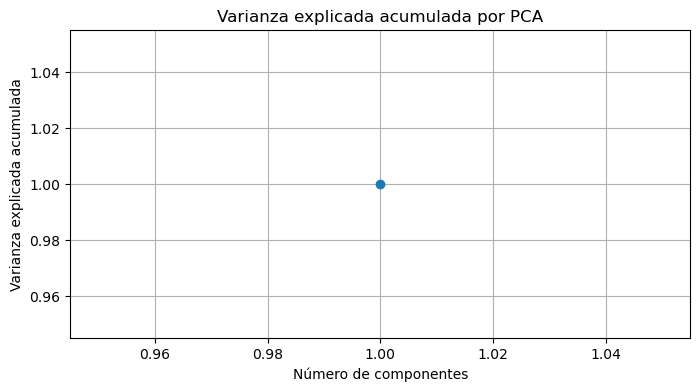

In [61]:
# ============================================================
# 19. Análisis de Componentes Principales PCA
# ============================================================

# PCA busca representar la información original en menos dimensiones.
# Se configura para conservar el 95% de la varianza.
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_corr_selected_df)

print("Número de variables antes de PCA:", X_corr_selected_df.shape[1])
print("Número de componentes después de PCA:", X_pca.shape[1])
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Visualizamos la varianza explicada acumulada
explained_variance_cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained_variance_cumsum) + 1), explained_variance_cumsum, marker="o")
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.show()

## 5. Conclusión CRISP-ML

En el contexto de CRISP-ML(Q), la fase de preparación de datos permitió convertir datos geográficos crudos y enriquecidos en un conjunto estructurado de características aptas para modelado. Esta etapa no solo buscó mejorar el desempeño predictivo, sino también fortalecer la calidad, trazabilidad y confiabilidad del dataset. La creación de variables de movilidad, accesibilidad y calidad del dato permitió incorporar conocimiento del dominio financiero y geográfico, mientras que la eliminación de variables de alta cardinalidad o sensibilidad potencial contribuyó a mitigar riesgos de sobreajuste y sesgo.

Como resultado, se generó un dataset más robusto, interpretable y preparado para la fase de modelado. No obstante, se identificó que algunas variables, especialmente las provenientes de Places API, presentan baja cobertura y deben utilizarse con cautela. Asimismo, las variables geográficas deben ser evaluadas posteriormente mediante métricas de equidad y análisis de sesgo para asegurar que el modelo no discrimine indirectamente por ubicación, nivel socioeconómico o disponibilidad desigual de infraestructura financiera.